In [ ]:
# ============================================================
# INSTALL DEPENDENCIES (Google Colab)
# ============================================================
# Run this cell once — restart runtime if prompted
!pip install -q pmdarima lightgbm xgboost scipy statsmodels scikit-learn folium
print("\n✅ All dependencies installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.3 MB/s eta 0:00:00

✅ All dependencies installed successfully!


## Imports
_Run the install cell above first if on Google Colab._

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima as pm_auto_arima
import lightgbm as lgb
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

import warnings
# Targeted suppression: only suppress known convergence/fitting warnings
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*convergence.*')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print("All libraries imported successfully!")
print("  - pmdarima (auto_arima) for automatic ARIMA order selection")
print("  - xgboost for XGBoost forecasting model [Safat et al., 2021]")
print("  - KMeans for risk zone clustering [Akhter & Ferdouse, 2025]")
print("  - adfuller for stationarity testing [Safat et al., 2021]")
print("  - scipy for spatial correlation analysis")

All libraries imported successfully!
  - pmdarima (auto_arima) for automatic ARIMA order selection
  - xgboost for XGBoost forecasting model [Safat et al., 2021]
  - KMeans for risk zone clustering [Akhter & Ferdouse, 2025]
  - adfuller for stationarity testing [Safat et al., 2021]
  - scipy for spatial correlation analysis


Load Dataset

In [ ]:
df = pd.read_csv("LA_Crime_Data_from_2020_to_2024.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (955339, 28)


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


### Dataset Provenance & Ethical Statement

In [ ]:
# ============================================================
# DATASET PROVENANCE
# ============================================================
# Source: City of Los Angeles Open Data Portal
# URL: https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8
#
# This dataset contains crime incident records reported to the
# Los Angeles Police Department (LAPD) from January 2020 onward.
# Each record represents a single reported crime with attributes
# including date, time, location (LAT/LON), area, crime type,
# victim demographics, and case status.
#
# Ethical Use Statement:
# - Data is used solely for aggregate trend analysis and forecasting
# - No individual-level prediction or profiling is performed
# - All analysis operates on monthly aggregated counts
# - The dataset is publicly available under LA Open Data Terms of Use
# ============================================================

print("Dataset: Crime Data from 2020 to Present")
print("Source:  City of Los Angeles Open Data Portal (data.lacity.org)")
print("License: Public Domain / LA Open Data Terms of Use")
print(f"File:    LA_Crime_Data_from_2020_to_2024.csv")
print(f"Records: {df.shape[0]:,} | Features: {df.shape[1]}")

Dataset: Crime Data from 2020 to Present
Source:  City of Los Angeles Open Data Portal (data.lacity.org)
License: Public Domain / LA Open Data Terms of Use
File:    LA_Crime_Data_from_2020_to_2024.csv
Records: 955,339 | Features: 28


Basic Dataset Info

In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

DATASET OVERVIEW
Total Records: 955,339
Total Features: 28

Column Names:
['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON']

Data Types:
DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          fl

Data Cleaning & Preparation

In [ ]:
# Convert date columns
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

# Drop rarely used secondary crime code columns
df.drop(columns=['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'], inplace=True, errors='ignore')

# Fill missing values
df['Weapon Desc'] = df['Weapon Desc'].fillna('No Weapon Reported')
df['Vict Sex'] = df['Vict Sex'].fillna('Unknown')
df['Vict Descent'] = df['Vict Descent'].fillna('Unknown').str.upper()

# Extract temporal features
df['Occ_Year'] = df['DATE OCC'].dt.year
df['Occ_Month'] = df['DATE OCC'].dt.month
df['Occ_Month_Name'] = df['DATE OCC'].dt.month_name()
df['Occ_Day'] = df['DATE OCC'].dt.day
df['Occ_DayOfWeek'] = df['DATE OCC'].dt.day_name()
df['Occ_Hour'] = df['TIME OCC'] // 100

print("Data cleaning complete!")
print(f"\nRemaining null values:\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

/tmp/ipykernel_459/1369034891.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
/tmp/ipykernel_459/1369034891.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


Data cleaning complete!

Remaining null values:
Cross Street      806439
Weapon Used Cd    630320
Mocodes           136675
Premis Desc          569
Premis Cd             12
Crm Cd 1              11
Status                 1
Rpt Dist No            0
AREA NAME              0
Crm Cd                 0
dtype: int64


Filter to Complete Years (2020–2023) — 2024 Excluded (Incomplete)

In [ ]:
print(f"\nCrime counts by year:")
print(df['Occ_Year'].value_counts().sort_index())

# 2024 data is incomplete — keep only 2020–2023 for modeling
df_full = df[df['Occ_Year'] <= 2023].copy()
print(f"\nFiltered dataset (2020–2023): {df_full.shape[0]:,} records")


Crime counts by year:
Occ_Year
2020    199725
2021    209731
2022    235027
2023    231823
2024     79033
Name: count, dtype: int64

Filtered dataset (2020–2023): 876,306 records


## Combined EDA: Crime Trends, Types & Area Distribution
Four key dimensions merged into a single panel (per professor feedback).

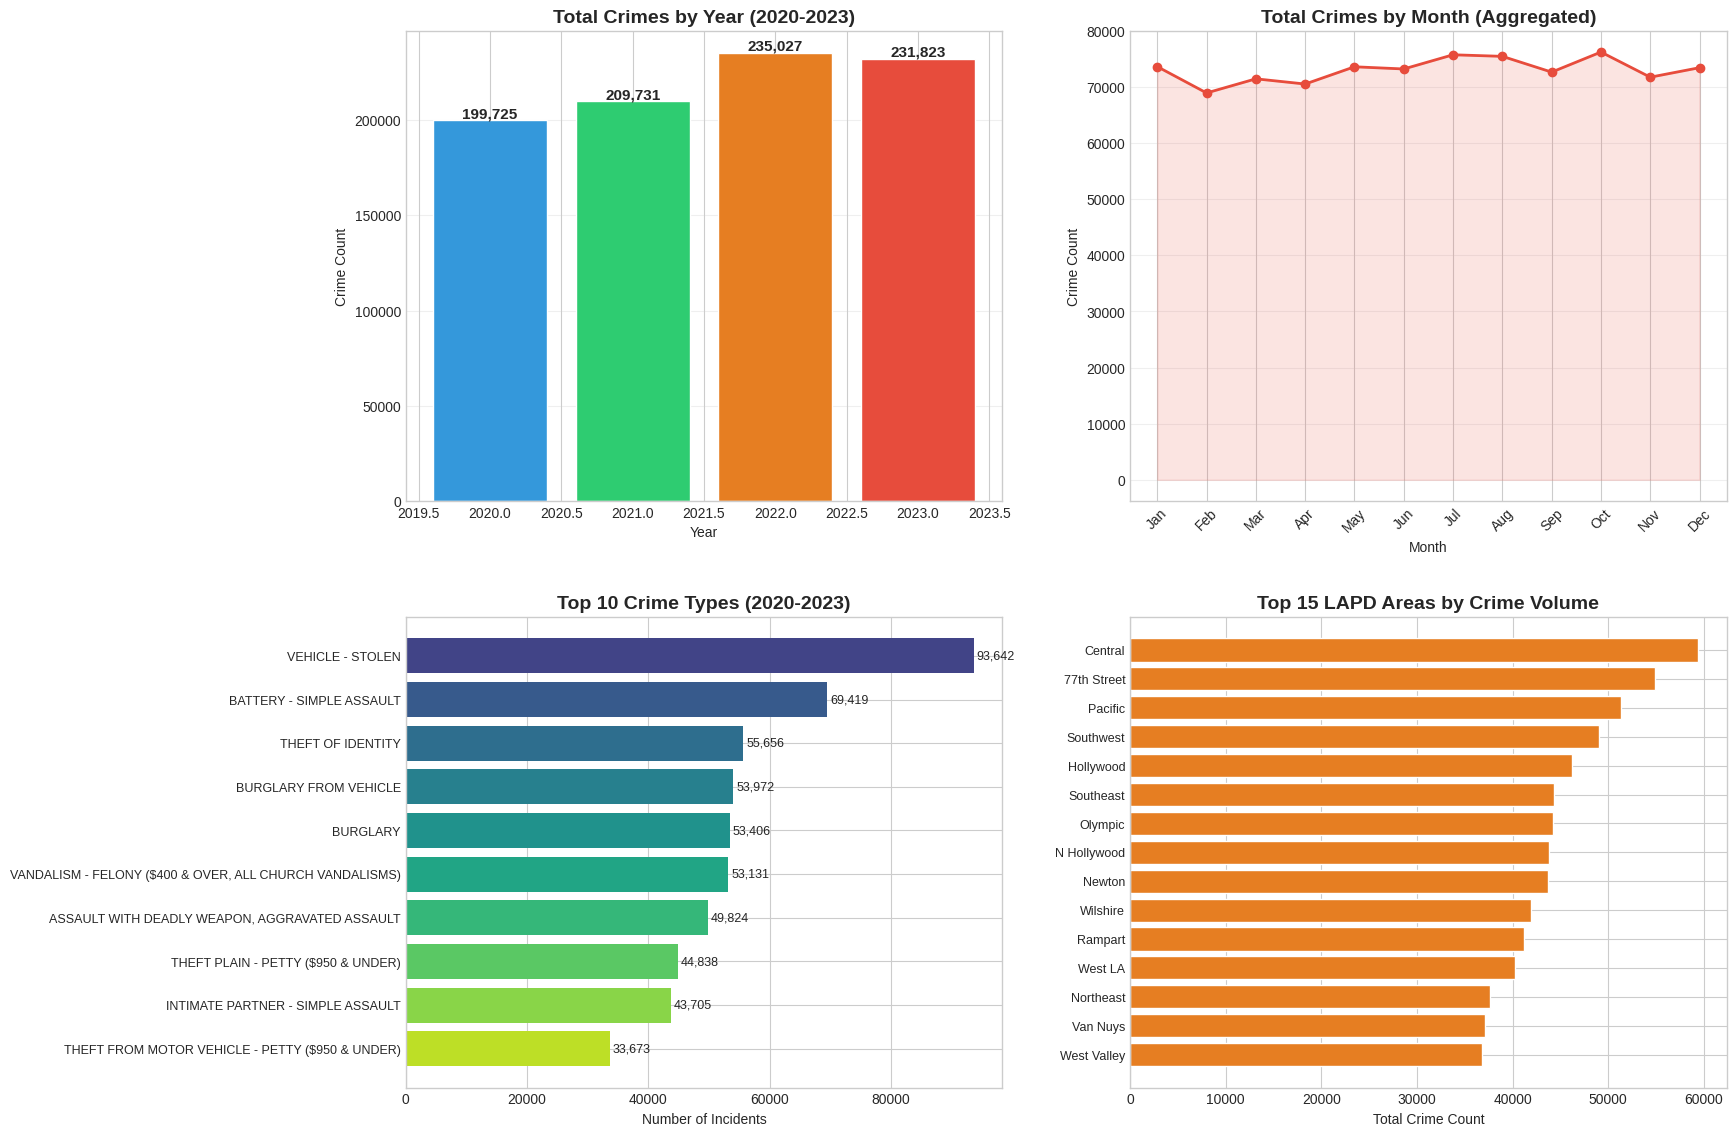

In [ ]:
# ============================================================
# COMBINED EDA: Year + Month + Crime Types + Areas (2x2)
# Professor feedback: "Merge 4 graphs into one"
# ============================================================
# Define variables needed by later cells
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df_full['Hour'] = df_full['TIME OCC'] // 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: Crime by Year
yearly = df_full.groupby('Occ_Year').size()
colors_y = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']
axes[0,0].bar(yearly.index, yearly.values, color=colors_y, edgecolor='white')
for idx, val in enumerate(yearly.values):
    axes[0,0].text(yearly.index[idx], val + 1500, f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0,0].set_title('Total Crimes by Year (2020-2023)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Crime Count')
axes[0,0].grid(axis='y', alpha=0.3)

# Panel 2: Crime by Month (aggregated)
monthly_agg = df_full.groupby(df_full['DATE OCC'].dt.month).size()
short_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].plot(range(1,13), monthly_agg.values, marker='o', color='#E74C3C', linewidth=2)
axes[0,1].fill_between(range(1,13), monthly_agg.values, alpha=0.15, color='#E74C3C')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(short_months, rotation=45)
axes[0,1].set_title('Total Crimes by Month (Aggregated)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Crime Count')
axes[0,1].grid(axis='y', alpha=0.3)

# Panel 3: Top 10 Crime Types
top_crimes = df_full['Crm Cd Desc'].value_counts().head(10)
axes[1,0].barh(range(len(top_crimes)), top_crimes.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, 10)))
axes[1,0].set_yticks(range(len(top_crimes)))
axes[1,0].set_yticklabels(top_crimes.index, fontsize=9)
for idx, val in enumerate(top_crimes.values):
    axes[1,0].text(val + 500, idx, f'{val:,}', va='center', fontsize=9)
axes[1,0].set_title('Top 10 Crime Types (2020-2023)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Incidents')
axes[1,0].invert_yaxis()

# Panel 4: Top 15 LAPD Areas
area_counts = df_full['AREA NAME'].value_counts().head(15)
axes[1,1].barh(range(len(area_counts)), area_counts.values, color='#E67E22', edgecolor='white')
axes[1,1].set_yticks(range(len(area_counts)))
axes[1,1].set_yticklabels(area_counts.index, fontsize=9)
axes[1,1].set_title('Top 15 LAPD Areas by Crime Volume', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Total Crime Count')
axes[1,1].invert_yaxis()

plt.tight_layout(pad=3.0)
plt.show()

## Combined EDA: Hourly & Daily Patterns
Temporal crime distributions merged into one panel.

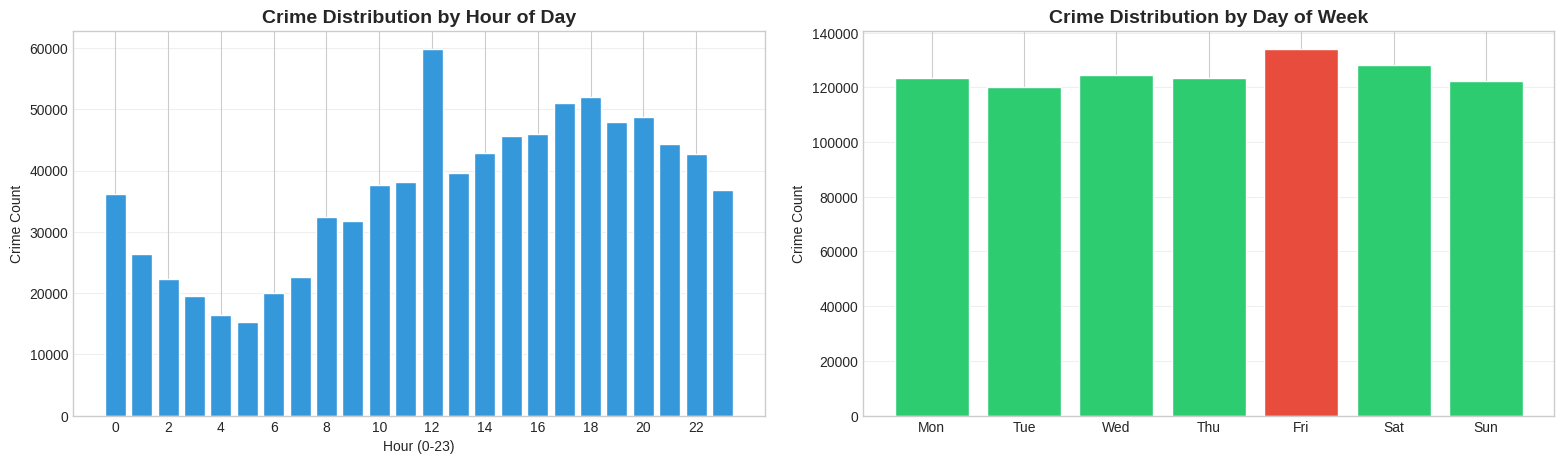

In [ ]:
# ============================================================
# COMBINED EDA: Hour + Day of Week (1x2)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Crime by Hour
hourly = df_full['Hour'].value_counts().sort_index()
axes[0].bar(hourly.index, hourly.values, color='#3498DB', edgecolor='white', width=0.8)
axes[0].set_title('Crime Distribution by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Crime Count')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Crime by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df_full['DATE OCC'].dt.day_name().value_counts().reindex(day_order)
colors_d = ['#2ECC71' if d != 'Friday' else '#E74C3C' for d in day_order]
axes[1].bar(range(7), daily.values, color=colors_d, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Crime Distribution by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Crime Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(pad=2.0)
plt.show()

Victim Demographics — Sex Distribution

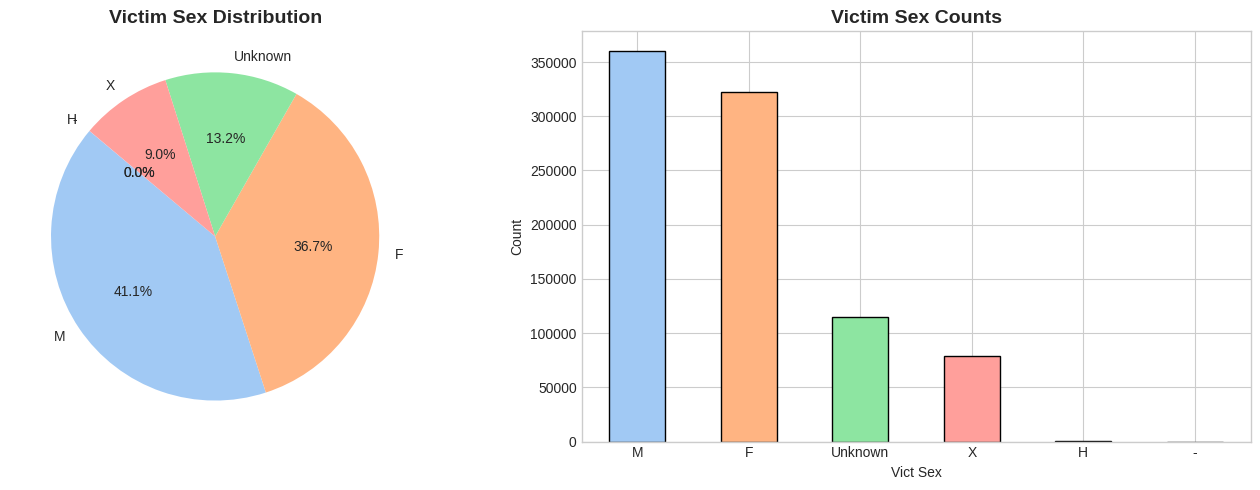

In [ ]:
vict_sex = df_full['Vict Sex'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(vict_sex, labels=vict_sex.index, autopct='%1.1f%%',
            colors=sns.color_palette("pastel"), startangle=140)
axes[0].set_title('Victim Sex Distribution', fontsize=14, fontweight='bold')

# Bar chart
vict_sex.plot(kind='bar', ax=axes[1], color=sns.color_palette("pastel"), edgecolor='black')
axes[1].set_title('Victim Sex Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Victim Age Distribution

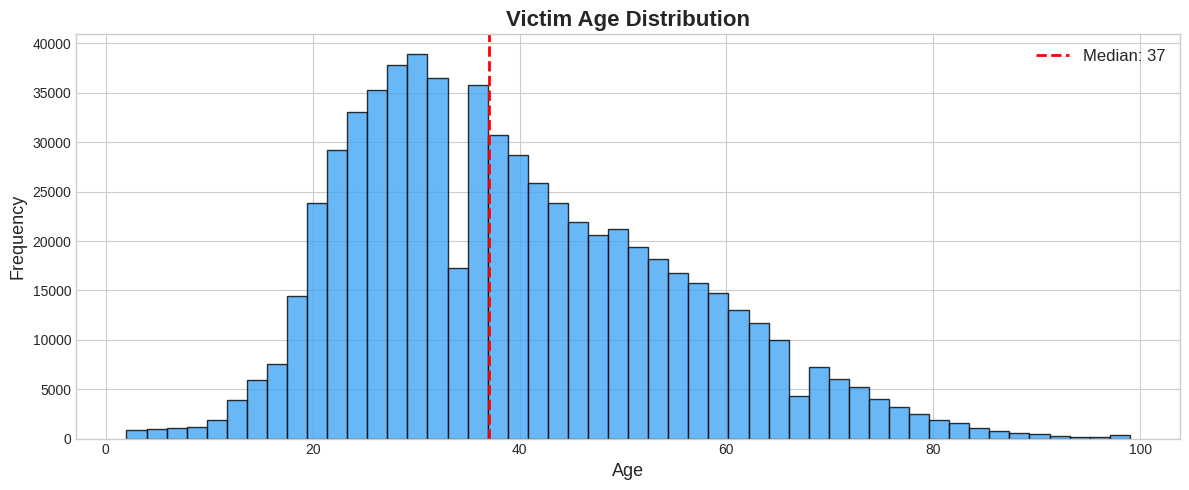

In [ ]:
valid_age = df_full[(df_full['Vict Age'] > 0) & (df_full['Vict Age'] < 100)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(valid_age['Vict Age'], bins=50, color='#42A5F5', edgecolor='black', alpha=0.8)
ax.axvline(valid_age['Vict Age'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: {valid_age['Vict Age'].median():.0f}")
ax.set_title('Victim Age Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

Weapon Usage Analysis

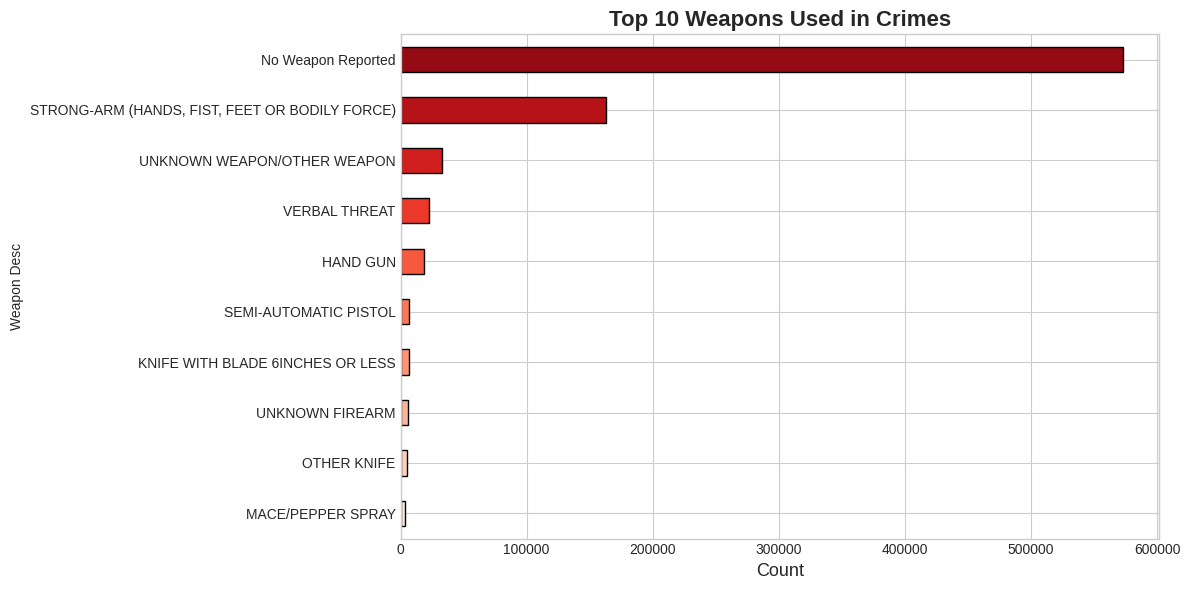

In [ ]:
weapon_counts = df_full['Weapon Desc'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
weapon_counts.plot(kind='barh', ax=ax, color=sns.color_palette("Reds_r", 10), edgecolor='black')
ax.set_title('Top 10 Weapons Used in Crimes', fontsize=16, fontweight='bold')
ax.set_xlabel('Count', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Heatmap — Crime by Month and Year

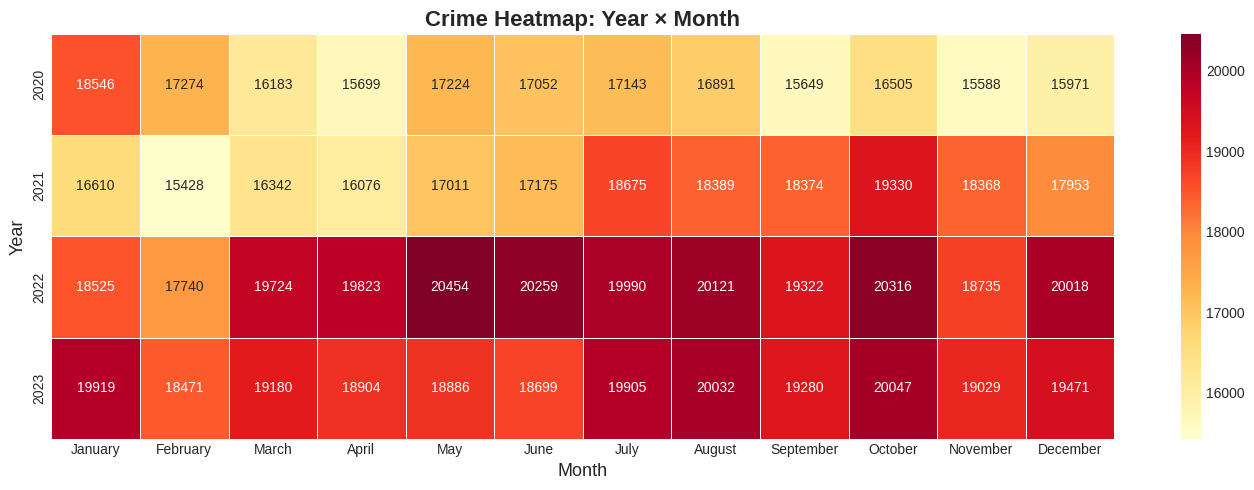

In [ ]:
heatmap_data = df_full.groupby(['Occ_Year', 'Occ_Month']).size().unstack(fill_value=0)
heatmap_data.columns = month_order

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Crime Heatmap: Year × Month', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Year', fontsize=13)
plt.tight_layout()
plt.show()

Correlation Analysis

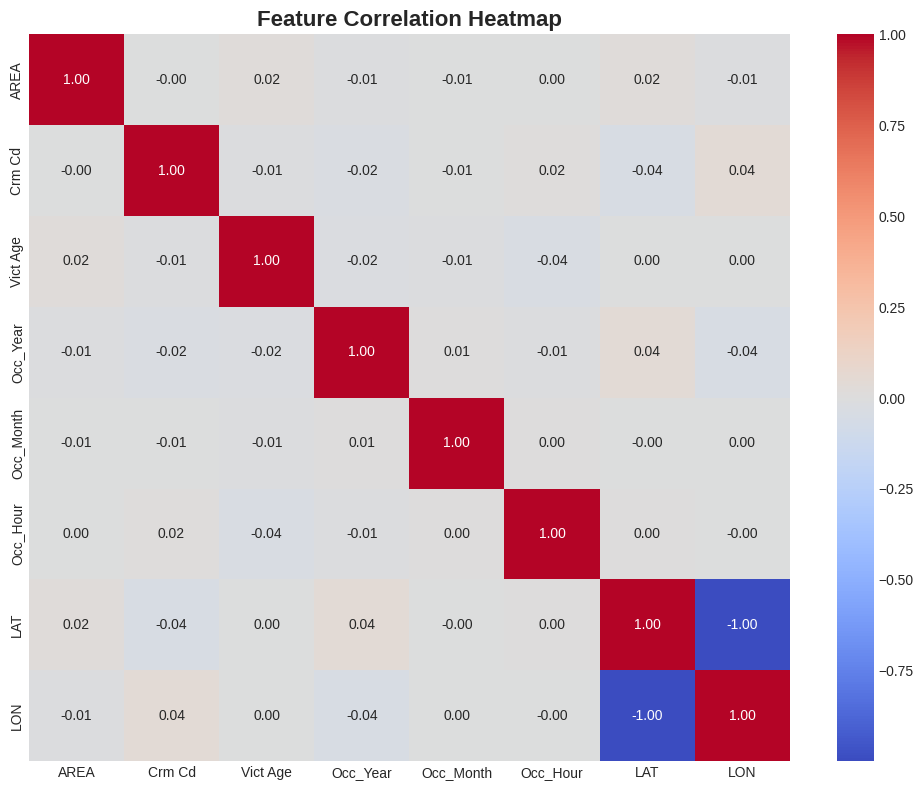

In [ ]:
numeric_cols = df_full[['AREA', 'Crm Cd', 'Vict Age', 'Occ_Year', 'Occ_Month', 'Occ_Hour', 'LAT', 'LON']].copy()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Status of Crimes

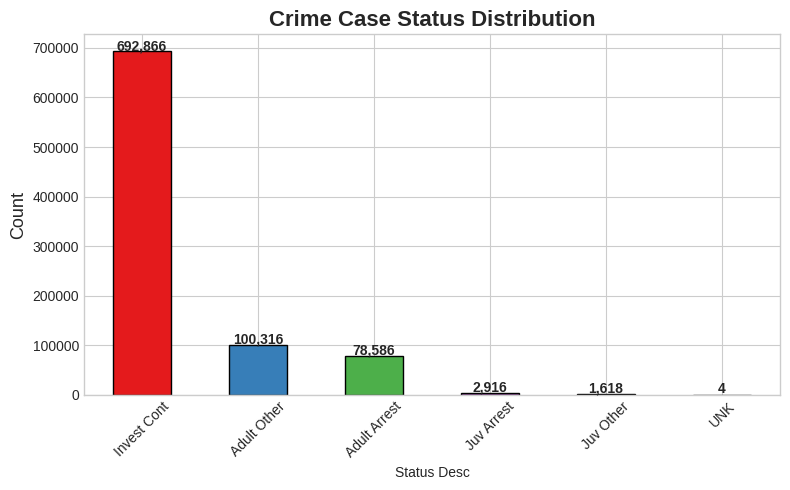

In [ ]:
status_counts = df_full['Status Desc'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
status_counts.plot(kind='bar', ax=ax, color=sns.color_palette("Set1"), edgecolor='black')
ax.set_title('Crime Case Status Distribution', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=13)
plt.xticks(rotation=45)
for i, v in enumerate(status_counts):
    ax.text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Spatial Analysis — Crime Geographic Distribution

Records with valid coordinates: 874,042 / 876,306 (99.7%)


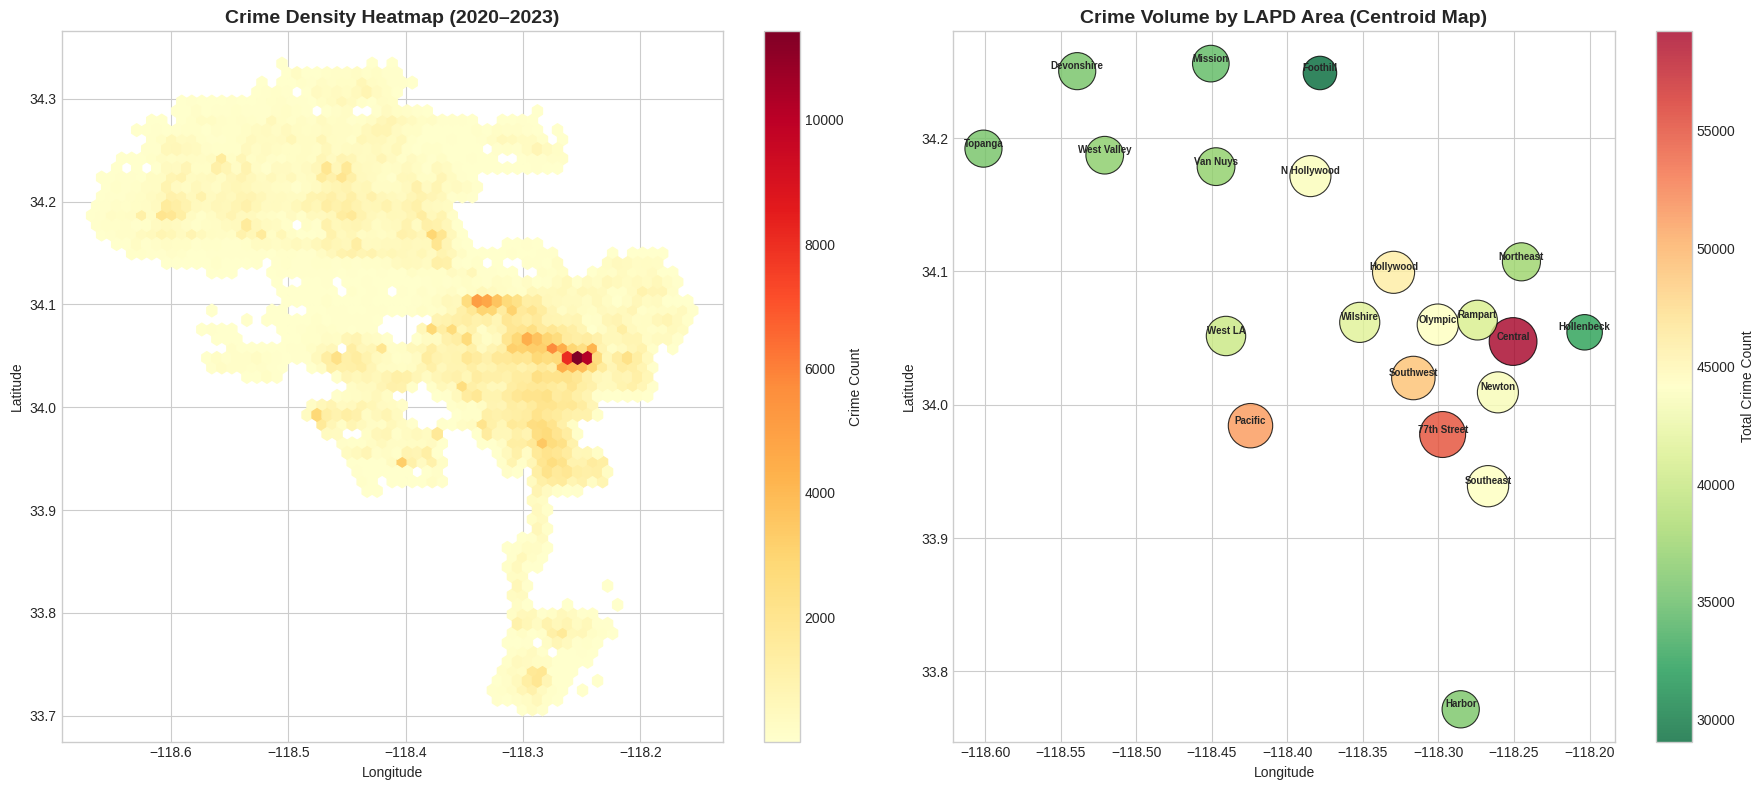


Top 5 areas by total crime count:
  AREA NAME  lat_mean    lon_mean  crime_count
    Central 34.047434 -118.250590        59224
77th Street 33.977667 -118.297221        54772
    Pacific 33.984283 -118.424370        51113
  Southwest 34.020052 -118.316593        49020
  Hollywood 34.099348 -118.329696        45913


In [ ]:
# ============================================================
# SPATIAL EDA: Crime Hotspot Visualization
# ============================================================
# Filter valid coordinates (exclude 0,0 which are missing/null locations)
df_geo = df_full[(df_full['LAT'] != 0) & (df_full['LON'] != 0)].copy()
print(f"Records with valid coordinates: {len(df_geo):,} / {len(df_full):,} ({len(df_geo)/len(df_full)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Scatter density plot of all crime locations
ax = axes[0]
hb = ax.hexbin(df_geo['LON'], df_geo['LAT'], gridsize=60, cmap='YlOrRd', mincnt=1)
ax.set_title('Crime Density Heatmap (2020\u20132023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cb = plt.colorbar(hb, ax=ax, label='Crime Count')

# Right: Crime density by LAPD area with centroids
ax = axes[1]
area_geo = df_geo.groupby('AREA NAME').agg(
    lat_mean=('LAT', 'mean'),
    lon_mean=('LON', 'mean'),
    crime_count=('DR_NO', 'count')
).reset_index()
scatter = ax.scatter(area_geo['lon_mean'], area_geo['lat_mean'],
                     s=area_geo['crime_count']/50,
                     c=area_geo['crime_count'], cmap='RdYlGn_r',
                     edgecolors='black', linewidth=0.8, alpha=0.8)
for _, row in area_geo.iterrows():
    ax.annotate(row['AREA NAME'], (row['lon_mean'], row['lat_mean']),
                fontsize=7, ha='center', va='bottom', fontweight='bold')
ax.set_title('Crime Volume by LAPD Area (Centroid Map)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(scatter, ax=ax, label='Total Crime Count')

plt.tight_layout()
plt.show()

print(f"\nTop 5 areas by total crime count:")
print(area_geo.sort_values('crime_count', ascending=False).head().to_string(index=False))

Spatial Correlation Between Areas

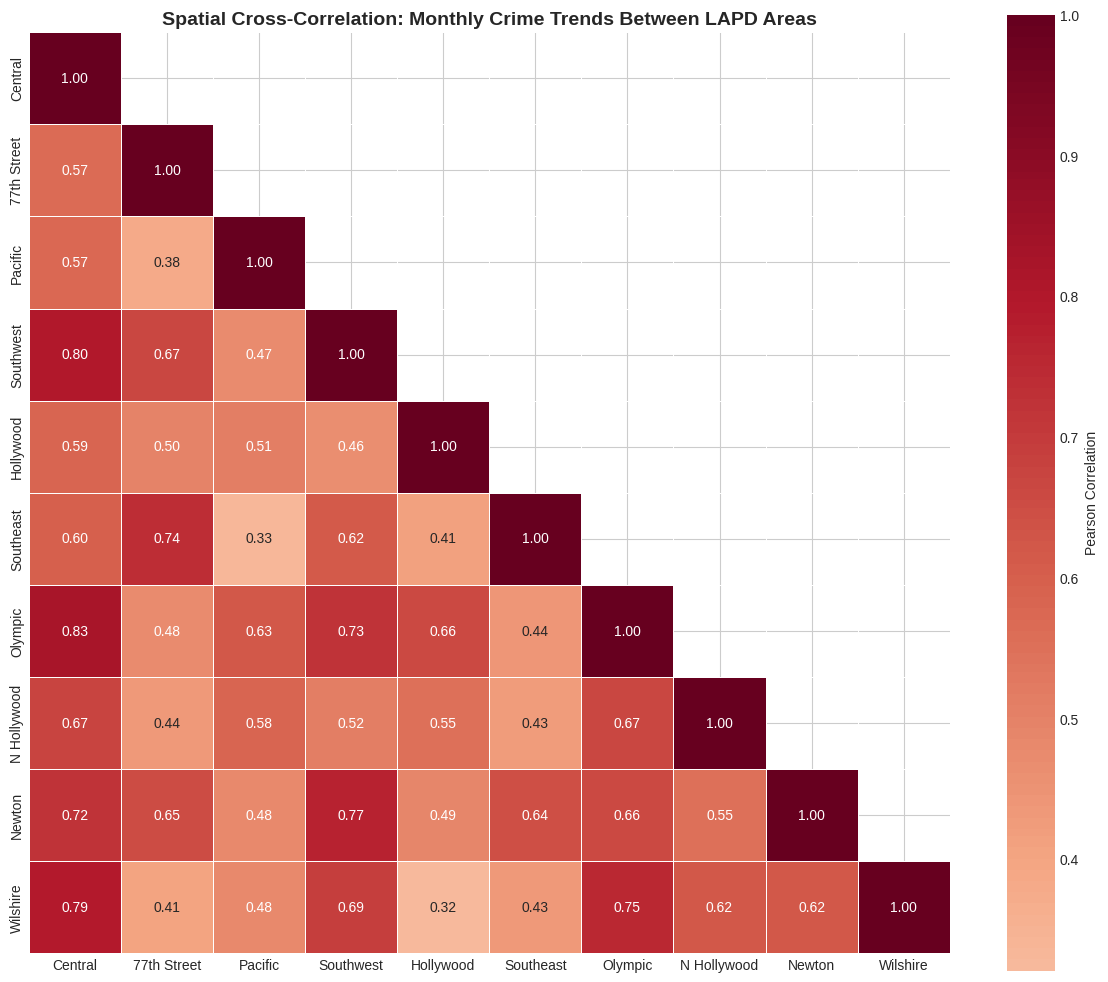


Highly correlated area pairs (|r| > 0.7):
  Central <-> Olympic: r = 0.827
  Central <-> Southwest: r = 0.803
  Central <-> Wilshire: r = 0.793
  Southwest <-> Newton: r = 0.769
  Olympic <-> Wilshire: r = 0.754
  77th Street <-> Southeast: r = 0.74
  Southwest <-> Olympic: r = 0.726
  Central <-> Newton: r = 0.724

Average inter-area correlation: 0.576
→ This indicates moderate spatial dependence in crime trends across LA.


In [ ]:
# ============================================================
# SPATIAL CROSS-CORRELATION: How correlated are crime trends between areas?
# ============================================================
# Build a matrix of monthly crime counts per area (all areas, not just top 5)
top_areas_for_spatial = df_full['AREA NAME'].value_counts().head(10).index.tolist()

area_ts_matrix = pd.DataFrame()
for area in top_areas_for_spatial:
    ts = (df_full[df_full['AREA NAME'] == area]
          .set_index('DATE OCC')
          .resample('M')
          .size()
          .rename(area))
    area_ts_matrix = pd.concat([area_ts_matrix, ts], axis=1)

area_ts_matrix = area_ts_matrix.fillna(0)

# Compute Pearson correlation matrix between area time series
corr_matrix = area_ts_matrix.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Spatial Cross-Correlation: Monthly Crime Trends Between LAPD Areas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated area pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], round(r, 3)))

print(f"\nHighly correlated area pairs (|r| > 0.7):")
for a1, a2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {a1} <-> {a2}: r = {r}")

avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"\nAverage inter-area correlation: {avg_corr:.3f}")
strength = "strong" if avg_corr > 0.6 else "moderate" if avg_corr > 0.3 else "weak"
print(f"→ This indicates {strength} spatial dependence in crime trends across LA.")

Hierarchical Clustering of Areas by Crime Pattern Similarity

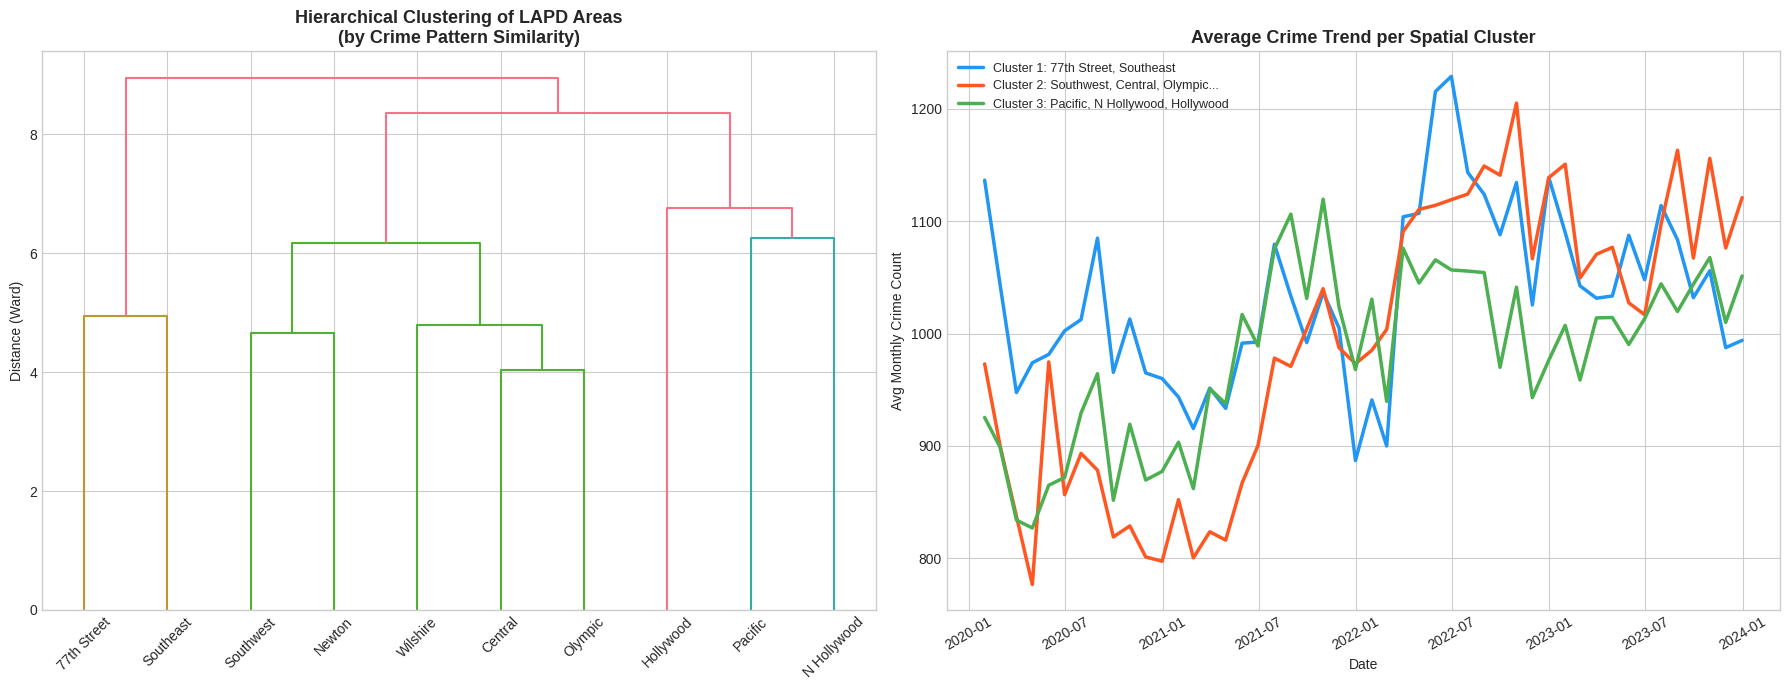


Area cluster assignments:
  Cluster 1: 77th Street, Southeast
  Cluster 2: Southwest, Central, Olympic, Newton, Wilshire
  Cluster 3: Pacific, N Hollywood, Hollywood


In [ ]:
# ============================================================
# SPATIAL CLUSTERING: Group areas with similar crime temporal patterns
# ============================================================
# Standardize each area's time series before clustering
area_ts_norm = (area_ts_matrix - area_ts_matrix.mean()) / area_ts_matrix.std()

# Hierarchical clustering using Ward's method
Z = linkage(area_ts_norm.T, method='ward', metric='euclidean')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Dendrogram
ax = axes[0]
dendrogram(Z, labels=area_ts_norm.columns.tolist(), ax=ax, leaf_rotation=45, leaf_font_size=10)
ax.set_title('Hierarchical Clustering of LAPD Areas\n(by Crime Pattern Similarity)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Distance (Ward)')

# Assign clusters (k=3)
n_clusters = 3
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
area_clusters = pd.DataFrame({
    'Area': area_ts_norm.columns,
    'Cluster': cluster_labels
}).sort_values('Cluster')

# Plot cluster means
ax = axes[1]
cluster_colors = ['#2196F3', '#FF5722', '#4CAF50']
for c in range(1, n_clusters + 1):
    cluster_areas = area_clusters[area_clusters['Cluster'] == c]['Area'].tolist()
    cluster_mean = area_ts_matrix[cluster_areas].mean(axis=1)
    ax.plot(cluster_mean.index, cluster_mean.values, linewidth=2.5,
            color=cluster_colors[c-1],
            label=f'Cluster {c}: {", ".join(cluster_areas[:3])}{"..." if len(cluster_areas) > 3 else ""}')
ax.set_title('Average Crime Trend per Spatial Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Monthly Crime Count')
ax.legend(fontsize=9, loc='upper left')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nArea cluster assignments:")
for c in range(1, n_clusters + 1):
    areas = area_clusters[area_clusters['Cluster'] == c]['Area'].tolist()
    print(f"  Cluster {c}: {', '.join(areas)}")

## Interactive Crime Maps (Folium)
_Interactive HTML maps for spatial exploration of crime hotspots_

In [ ]:
# ============================================================
# INTERACTIVE CRIME MAP 1: Clustered Crime Markers
# Generates: crime_map.html
# ============================================================
import folium
from folium.plugins import MarkerCluster

# Sample for performance
map_sample = df_full.sample(n=min(100000, len(df_full)), random_state=42)
map_sample = map_sample[(map_sample['LAT'] != 0) & (map_sample['LON'] != 0)]

center_point = [map_sample['LAT'].mean(), map_sample['LON'].mean()]

# Use a clean dark tile style
crime_map = folium.Map(
    location=center_point, zoom_start=10,
    tiles='CartoDB positron'
)

# MarkerCluster with custom icon colors
crime_marker_cluster = MarkerCluster(
    name="Crime Incidents",
    options={'maxClusterRadius': 50, 'disableClusteringAtZoom': 14}
).add_to(crime_map)

# Color map by crime type
crime_colors = {
    'VEHICLE - STOLEN': '#e74c3c',
    'BATTERY - SIMPLE ASSAULT': '#e67e22',
    'BURGLARY FROM VEHICLE': '#3498db',
    'THEFT OF IDENTITY': '#9b59b6',
    'BURGLARY': '#2ecc71'
}

for _, record in map_sample.iterrows():
    crime_type = record['Crm Cd Desc']
    color = crime_colors.get(crime_type, '#95a5a6')

    folium.CircleMarker(
        location=[record['LAT'], record['LON']],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{crime_type}</b><br>"
            f"Area: {record['AREA NAME']}<br>"
            f"Date: {record['DATE OCC'].strftime('%Y-%m-%d')}",
            max_width=250
        )
    ).add_to(crime_marker_cluster)

# Add a legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid #333; font-size: 13px; font-family: Arial;">
<b>Crime Types</b><br>
<i style="background:#e74c3c;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Vehicle Stolen<br>
<i style="background:#e67e22;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Battery/Assault<br>
<i style="background:#3498db;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Burglary from Vehicle<br>
<i style="background:#9b59b6;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Identity Theft<br>
<i style="background:#2ecc71;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Burglary<br>
<i style="background:#95a5a6;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Other
</div>
'''
crime_map.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl().add_to(crime_map)

crime_map.save("crime_map.html")
print("✅ crime_map.html saved — Color-coded clustered crime map")
print(f"   Records mapped: {len(map_sample):,}")
print("   Open in browser to explore interactively")

✅ crime_map.html saved — Color-coded clustered crime map
   Records mapped: 99,733
   Open in browser to explore interactively


### Interactive Crime Map by Type and Time of Day (2023)
_Layered map with toggleable crime categories and time segments_

In [ ]:
# ============================================================
# INTERACTIVE CRIME MAP 2: Crime Type x Time-of-Day Layers
# Generates: crime_map_2023.html
# ============================================================

data_2023 = df_full[df_full['Occ_Year'] == 2023].copy()
data_2023['occ_hour'] = data_2023['TIME OCC'] // 100

time_ranges = [0, 6, 12, 18, 24]
time_labels = ['0-6', '7-12', '13-18', '19-24']
time_color_map = {'0-6': '#3498db', '7-12': '#2ecc71', '13-18': '#e67e22', '19-24': '#e74c3c'}

data_2023['time_segment'] = pd.cut(
    data_2023['occ_hour'], bins=time_ranges,
    labels=time_labels, right=False, include_lowest=True
)

key_crimes = ["VEHICLE - STOLEN", "BATTERY - SIMPLE ASSAULT",
              "BURGLARY FROM VEHICLE", "THEFT OF IDENTITY", "BURGLARY"]

crime_focus = data_2023[
    (data_2023['Crm Cd Desc'].isin(key_crimes)) &
    (data_2023['LAT'] != 0) & (data_2023['LON'] != 0)
].copy()

# Sample to 15K for performance — this is the key fix
if len(crime_focus) > 15000:
    crime_focus = crime_focus.sample(n=15000, random_state=42)
    print(f"Sampled 15,000 from {len(data_2023):,} records for performance")

print(f"Mapping {len(crime_focus):,} records...")

crime_map_2023 = folium.Map(
    location=[crime_focus['LAT'].mean(), crime_focus['LON'].mean()],
    zoom_start=10, tiles='CartoDB positron'
)

# Build layers using vectorized groupby instead of row-by-row
for crime_name in key_crimes:
    for ts in time_labels:
        subset = crime_focus[
            (crime_focus['Crm Cd Desc'] == crime_name) &
            (crime_focus['time_segment'] == ts)
        ]
        if len(subset) == 0:
            continue

        fg = folium.FeatureGroup(name=f"{crime_name[:22]} | {ts}", show=False)
        color = time_color_map[ts]

        for _, row in subset.iterrows():
            folium.CircleMarker(
                location=[row['LAT'], row['LON']],
                radius=4, color=color, fill=True,
                fill_color=color, fill_opacity=0.6,
                popup=f"<b>{crime_name}</b><br>Time: {ts}<br>Area: {row['AREA NAME']}"
            ).add_to(fg)

        fg.add_to(crime_map_2023)
        print(f"  Layer: {crime_name[:22]} | {ts} — {len(subset)} markers")

folium.LayerControl(collapsed=False).add_to(crime_map_2023)

# Legend
legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px;border-radius:8px;border:2px solid #333;
     font-size:13px;font-family:Arial;">
<b>Time of Day</b><br>
<span style="color:#3498db;">&#9679;</span> 0-6h (Night)<br>
<span style="color:#2ecc71;">&#9679;</span> 7-12h (Morning)<br>
<span style="color:#e67e22;">&#9679;</span> 13-18h (Afternoon)<br>
<span style="color:#e74c3c;">&#9679;</span> 19-24h (Evening)
</div>'''
crime_map_2023.get_root().html.add_child(folium.Element(legend_html))

crime_map_2023.save("crime_map_2023.html")
print("\n✅ crime_map_2023.html saved successfully!")
print("   Toggle crime types and time segments using layer control")

Sampled 15,000 from 231,823 records for performance
Mapping 15,000 records...
  Layer: VEHICLE - STOLEN | 0-6 — 717 markers
  Layer: VEHICLE - STOLEN | 7-12 — 673 markers
  Layer: VEHICLE - STOLEN | 13-18 — 1179 markers
  Layer: VEHICLE - STOLEN | 19-24 — 1780 markers
  Layer: BATTERY - SIMPLE ASSAU | 0-6 — 385 markers
  Layer: BATTERY - SIMPLE ASSAU | 7-12 — 718 markers
  Layer: BATTERY - SIMPLE ASSAU | 13-18 — 1222 markers
  Layer: BATTERY - SIMPLE ASSAU | 19-24 — 1024 markers
  Layer: BURGLARY FROM VEHICLE | 0-6 — 391 markers
  Layer: BURGLARY FROM VEHICLE | 7-12 — 358 markers
  Layer: BURGLARY FROM VEHICLE | 13-18 — 597 markers
  Layer: BURGLARY FROM VEHICLE | 19-24 — 1075 markers
  Layer: THEFT OF IDENTITY | 0-6 — 350 markers
  Layer: THEFT OF IDENTITY | 7-12 — 871 markers
  Layer: THEFT OF IDENTITY | 13-18 — 863 markers
  Layer: THEFT OF IDENTITY | 19-24 — 273 markers
  Layer: BURGLARY | 0-6 — 645 markers
  Layer: BURGLARY | 7-12 — 446 markers
  Layer: BURGLARY | 13-18 — 717 mark

## Model Selection Rationale

We chose five models covering the full complexity spectrum:
- **Seasonal Naive**: Simple benchmark — any useful model must beat this.
- **Auto-ARIMA**: Classical parametric model with automatic order selection via AIC.
- **ETS (Holt-Winters)**: Decomposes series into trend, seasonality, and error.
- **LightGBM**: Gradient boosting with leaf-wise tree growth and 17 engineered features.
- **XGBoost**: Gradient boosting with extra regularization. Included because Safat et al. (2021) found it best on LA crime data.

We did not include deep learning (LSTM, Transformer) because 48 monthly observations is too few — these models need hundreds or thousands of time steps to train effectively. The goal was a fair comparison of well-chosen models under identical validation conditions, not an exhaustive search.

PART 2: TIME SERIES CONSTRUCTION

Construct City-Wide Monthly Time Series

City-wide monthly time series: 48 data points
Date range: 2020-01 to 2023-12


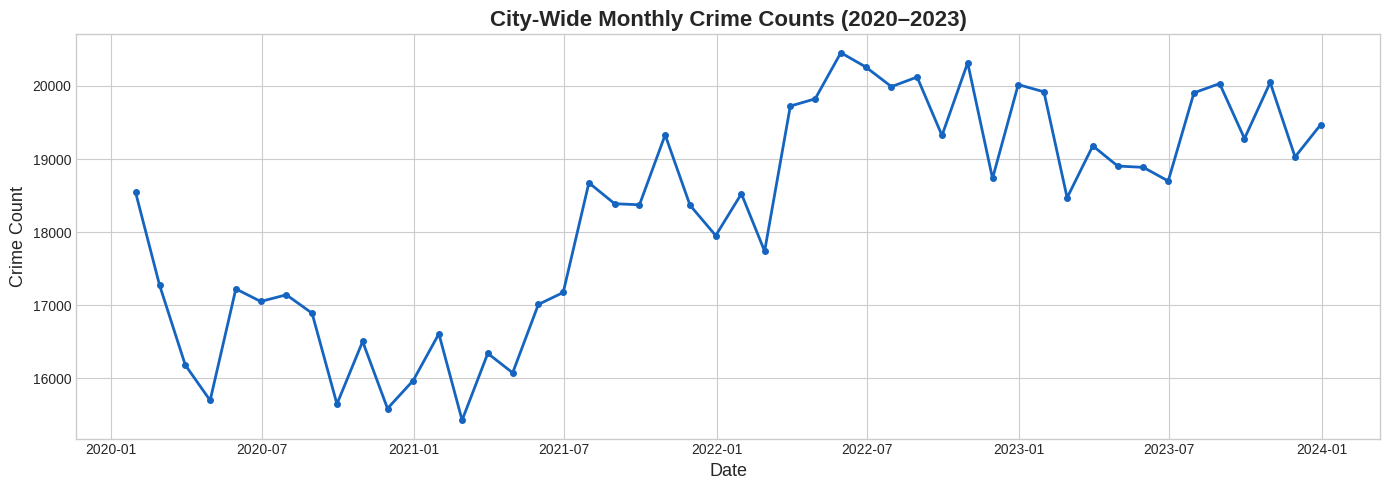

In [ ]:
city_monthly = (
    df_full.set_index('DATE OCC')
      .resample('M')
      .size()
      .rename('Crime_Count')
)
city_monthly.index.freq = 'M'

print(f"City-wide monthly time series: {len(city_monthly)} data points")
print(f"Date range: {city_monthly.index[0].strftime('%Y-%m')} to {city_monthly.index[-1].strftime('%Y-%m')}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(city_monthly.index, city_monthly.values, linewidth=2, color='#1565C0', marker='o', markersize=4)
ax.set_title('City-Wide Monthly Crime Counts (2020–2023)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Crime Count', fontsize=13)
plt.tight_layout()
plt.show()

Seasonal Decomposition

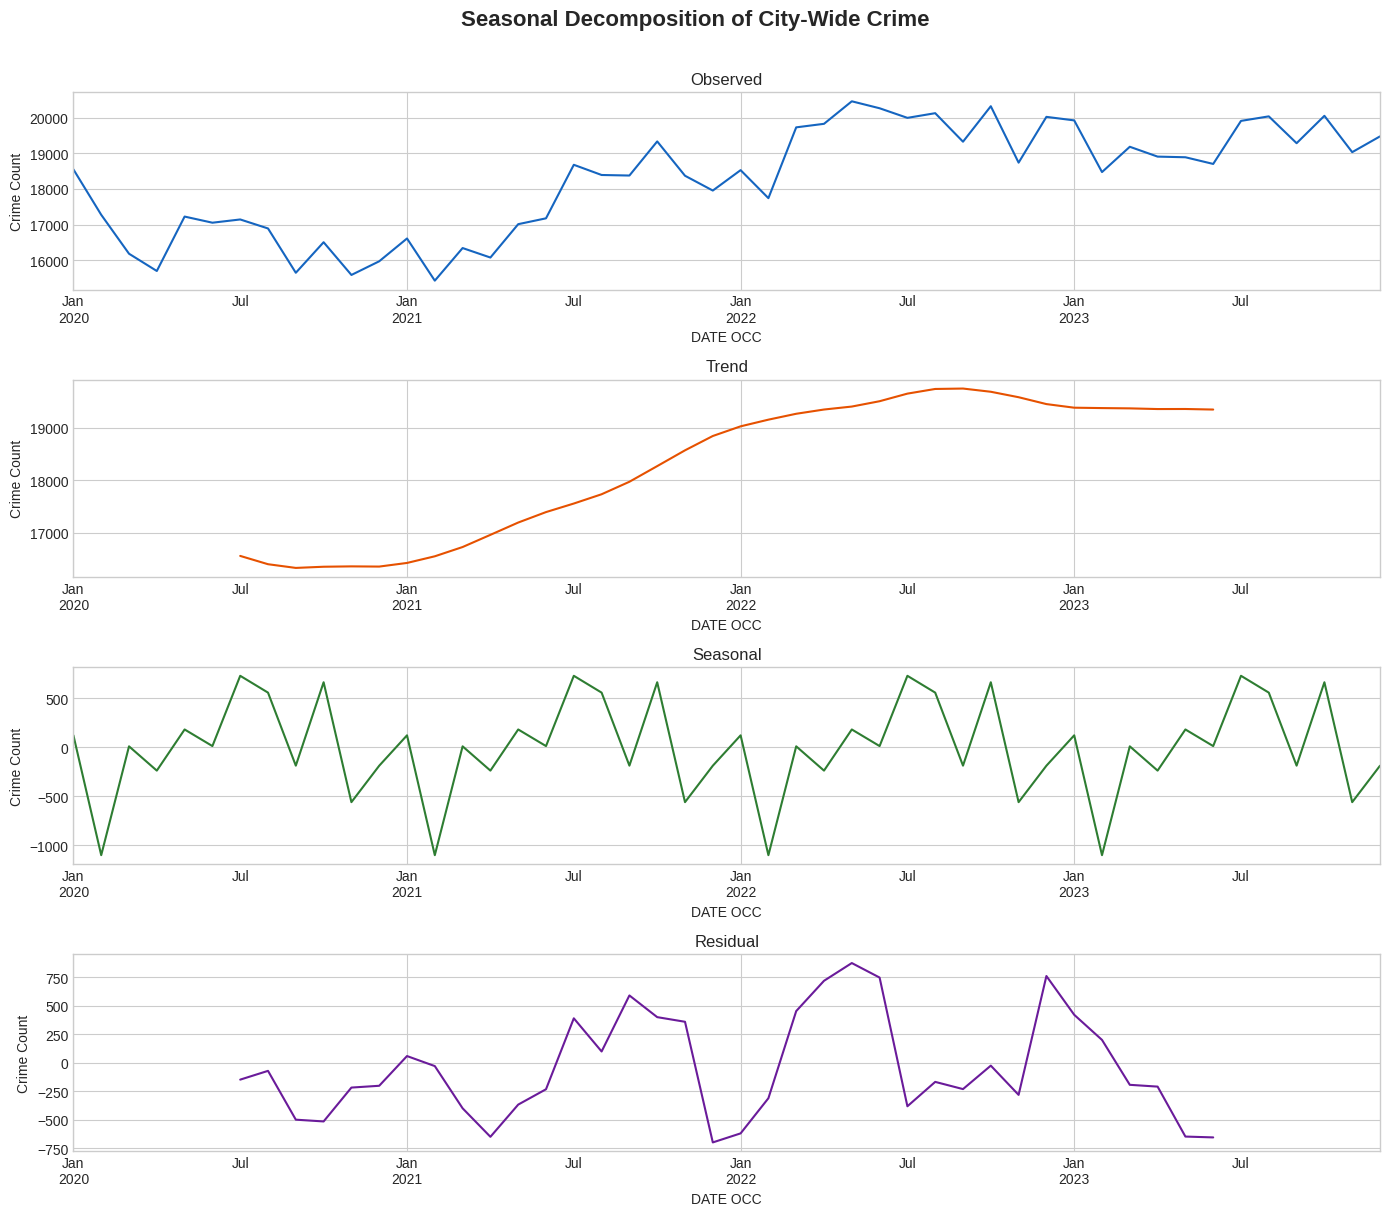

In [ ]:
decomposition = seasonal_decompose(city_monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed', color='#1565C0')
decomposition.trend.plot(ax=axes[1], title='Trend', color='#E65100')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='#2E7D32')
decomposition.resid.plot(ax=axes[3], title='Residual', color='#6A1B9A')
for ax in axes:
    ax.set_ylabel('Crime Count')
fig.suptitle('Seasonal Decomposition of City-Wide Crime', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Moving Average Trend Analysis
_Inspired by Kim et al. (2018) — crime trend analysis using moving averages [IEEE]_

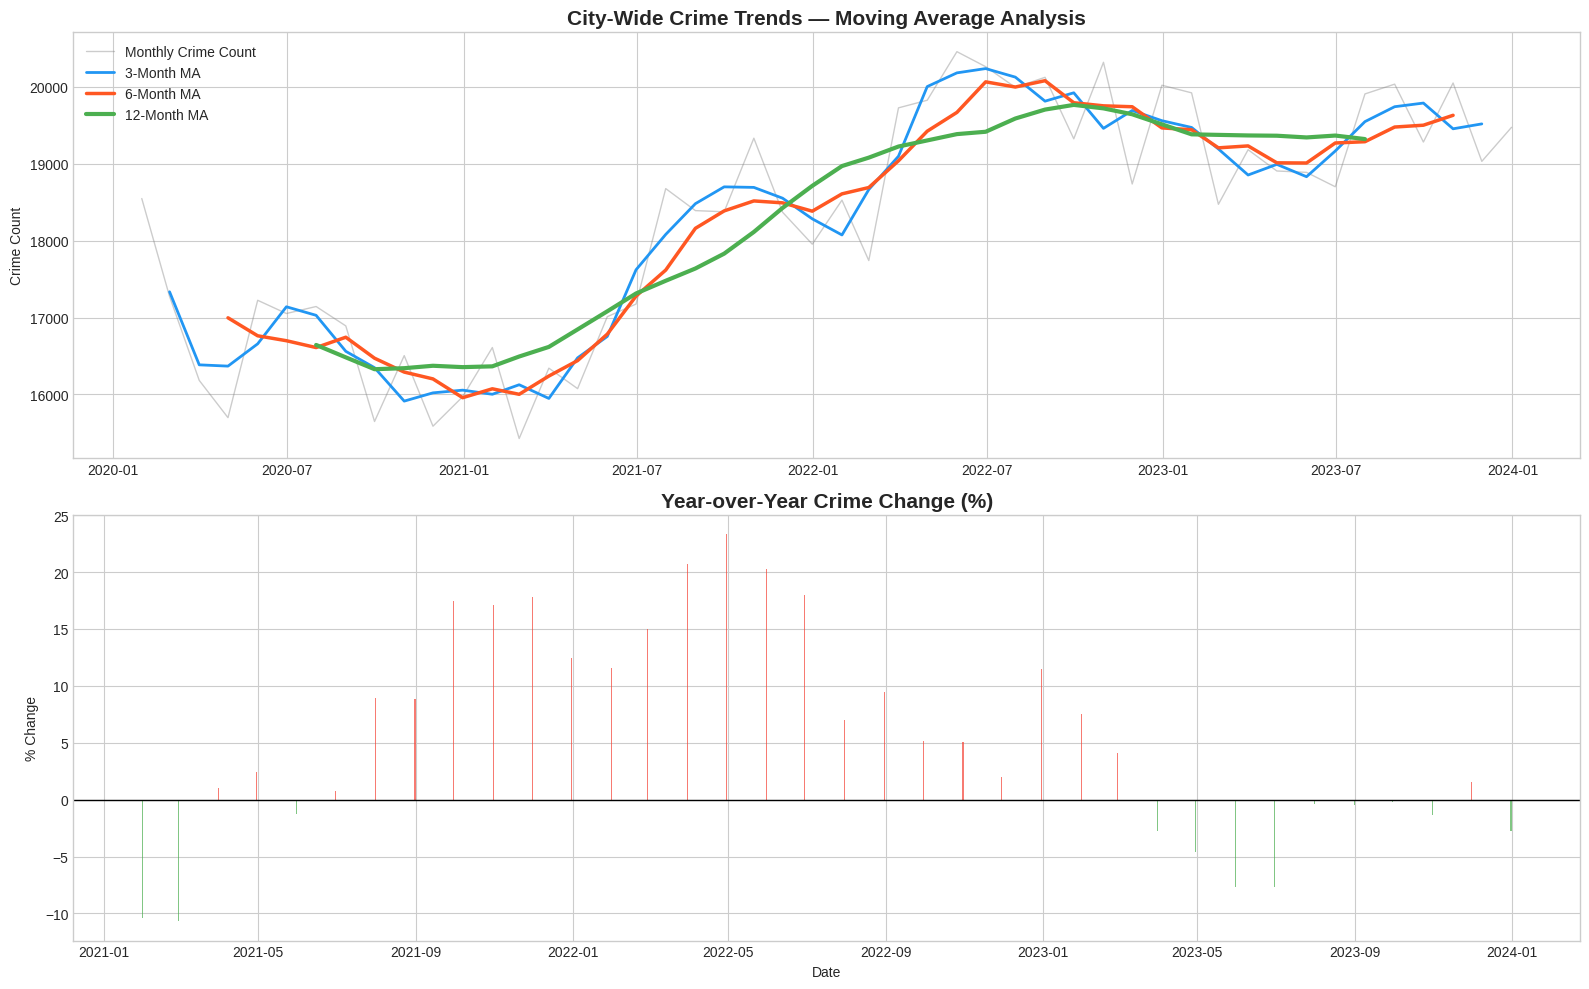


Average year-over-year change: 5.5%
→ Increasing overall crime trend in LA (2020–2023)


In [ ]:
# ============================================================
# MOVING AVERAGE TREND ANALYSIS [Kim et al., 2018]
# ============================================================
# Kim et al. used moving averages to reveal underlying crime trends
# in Vancouver data. We apply the same technique to LA crime data.

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 3-month and 6-month moving averages
city_monthly_df = city_monthly.to_frame()
city_monthly_df['MA_3'] = city_monthly.rolling(window=3, center=True).mean()
city_monthly_df['MA_6'] = city_monthly.rolling(window=6, center=True).mean()
city_monthly_df['MA_12'] = city_monthly.rolling(window=12, center=True).mean()

ax = axes[0]
ax.plot(city_monthly.index, city_monthly.values, alpha=0.4, linewidth=1, label='Monthly Crime Count', color='gray')
ax.plot(city_monthly_df.index, city_monthly_df['MA_3'], linewidth=2, label='3-Month MA', color='#2196F3')
ax.plot(city_monthly_df.index, city_monthly_df['MA_6'], linewidth=2.5, label='6-Month MA', color='#FF5722')
ax.plot(city_monthly_df.index, city_monthly_df['MA_12'], linewidth=3, label='12-Month MA', color='#4CAF50')
ax.set_title('City-Wide Crime Trends — Moving Average Analysis', fontsize=15, fontweight='bold')
ax.set_ylabel('Crime Count')
ax.legend(fontsize=10)

# Year-over-year percentage change
ax = axes[1]
yoy_change = city_monthly.pct_change(periods=12) * 100
ax.bar(yoy_change.index, yoy_change.values, color=['#4CAF50' if v < 0 else '#F44336' for v in yoy_change.values], alpha=0.7)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Year-over-Year Crime Change (%)', fontsize=15, fontweight='bold')
ax.set_ylabel('% Change')
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

avg_yoy = yoy_change.dropna().mean()
print(f"\nAverage year-over-year change: {avg_yoy:.1f}%")
print(f"→ {'Declining' if avg_yoy < 0 else 'Increasing'} overall crime trend in LA (2020–2023)")

Construct Area-Level Monthly Time Series (Top 5 Areas)

Top 5 crime areas: ['Central', '77th Street', 'Pacific', 'Southwest', 'Hollywood']


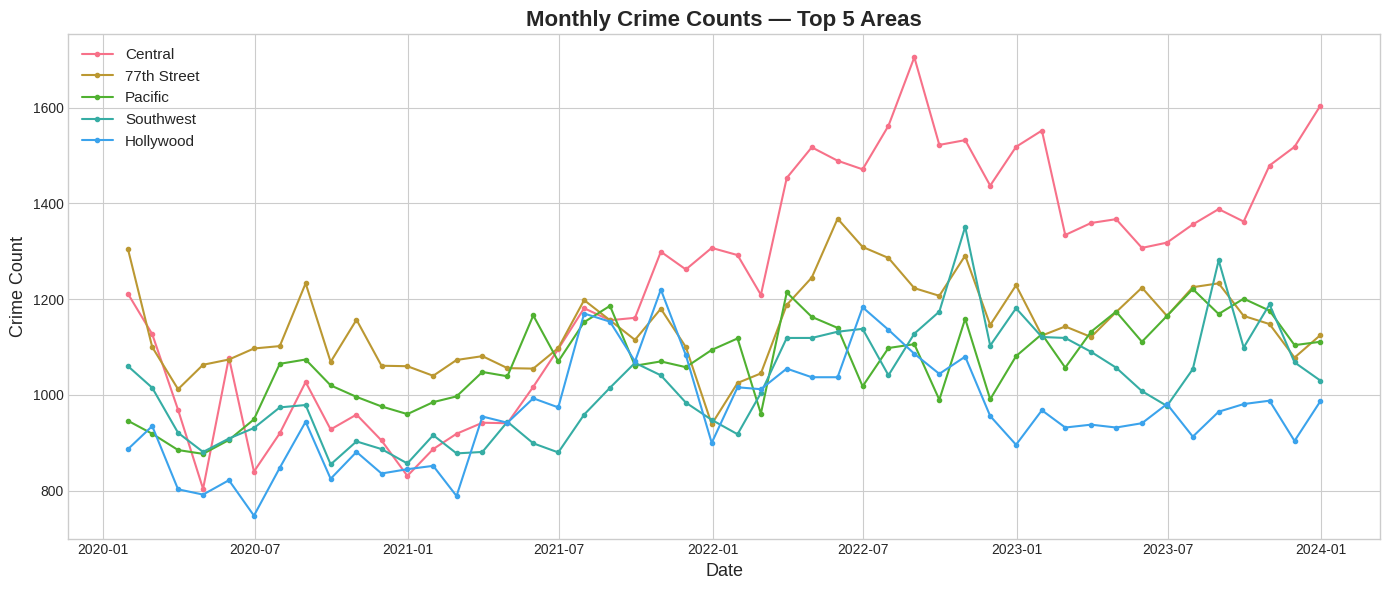

In [ ]:
top5_areas = df_full['AREA NAME'].value_counts().head(5).index.tolist()
print(f"Top 5 crime areas: {top5_areas}")

area_monthly = {}
for area in top5_areas:
    ts = (
        df_full[df_full['AREA NAME'] == area]
        .set_index('DATE OCC')
        .resample('M')
        .size()
        .rename('Crime_Count')
    )
    ts.index.freq = 'M'
    area_monthly[area] = ts

fig, ax = plt.subplots(figsize=(14, 6))
for area, ts in area_monthly.items():
    ax.plot(ts.index, ts.values, marker='o', markersize=3, linewidth=1.5, label=area)
ax.set_title('Monthly Crime Counts — Top 5 Areas', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Crime Count', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Construct Crime-Type Monthly Time Series (Top 5 Types)

Top 5 crime types: ['VEHICLE - STOLEN', 'BATTERY - SIMPLE ASSAULT', 'THEFT OF IDENTITY', 'BURGLARY FROM VEHICLE', 'BURGLARY']


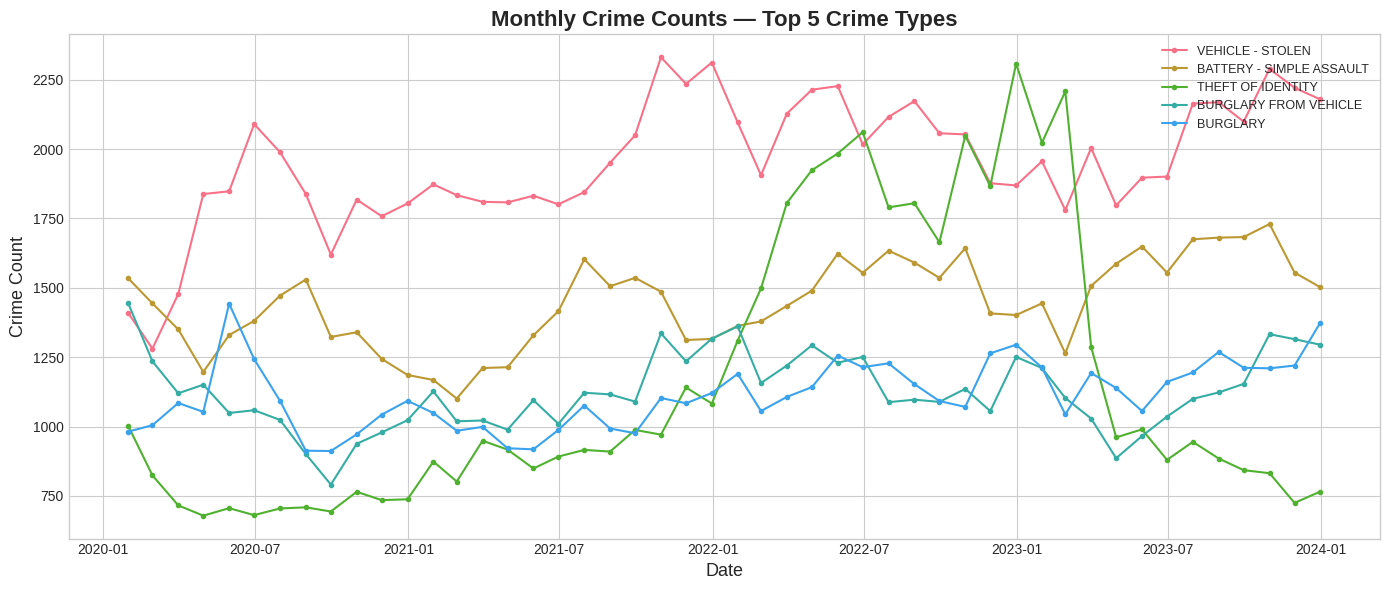

In [ ]:
top5_crimes_list = df_full['Crm Cd Desc'].value_counts().head(5).index.tolist()
print(f"Top 5 crime types: {top5_crimes_list}")

crime_type_monthly = {}
for crime in top5_crimes_list:
    ts = (
        df_full[df_full['Crm Cd Desc'] == crime]
        .set_index('DATE OCC')
        .resample('M')
        .size()
        .rename('Crime_Count')
    )
    ts.index.freq = 'M'
    crime_type_monthly[crime] = ts

fig, ax = plt.subplots(figsize=(14, 6))
for crime, ts in crime_type_monthly.items():
    ax.plot(ts.index, ts.values, marker='o', markersize=3, linewidth=1.5, label=crime[:40])
ax.set_title('Monthly Crime Counts — Top 5 Crime Types', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Crime Count', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

PART 3: FORECASTING MODELS

### Stationarity Testing (Augmented Dickey-Fuller)
_Following Safat et al. (2021) methodology for time series preprocessing [IEEE Access]_

In [ ]:
# ============================================================
# AUGMENTED DICKEY-FULLER STATIONARITY TEST [Safat et al., 2021]
# ============================================================
# Safat et al. emphasize that time series must be tested for
# stationarity before applying ARIMA-family models.
# H0: Series has a unit root (non-stationary)
# H1: Series is stationary

def run_adf_test(series, name="Series"):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test for {name}:")
    print(f"  Test Statistic:  {result[0]:.4f}")
    print(f"  p-value:         {result[1]:.6f}")
    print(f"  Lags Used:       {result[2]}")
    print(f"  Observations:    {result[3]}")
    for key, val in result[4].items():
        print(f"  Critical ({key}): {val:.4f}")

    if result[1] < 0.05:
        print(f"  → ✅ STATIONARY (p < 0.05): No differencing needed for {name}")
    else:
        print(f"  → ⚠️ NON-STATIONARY (p >= 0.05): Differencing recommended for {name}")
    print()
    return result[1] < 0.05

# Test city-wide series
print("=" * 60)
print("STATIONARITY ANALYSIS — AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)
print()

is_stationary = run_adf_test(city_monthly, "City-Wide Monthly Crime")

# Test first difference if non-stationary
if not is_stationary:
    print("Testing first difference (d=1):")
    run_adf_test(city_monthly.diff().dropna(), "City-Wide (1st Difference)")

# Test area-level series
print("\nArea-Level Stationarity:")
for area, ts in area_monthly.items():
    is_stat = run_adf_test(ts, area)

STATIONARITY ANALYSIS — AUGMENTED DICKEY-FULLER TEST

ADF Test for City-Wide Monthly Crime:
  Test Statistic:  -1.1874
  p-value:         0.678976
  Lags Used:       1
  Observations:    46
  Critical (1%): -3.5813
  Critical (5%): -2.9268
  Critical (10%): -2.6015
  → ⚠️ NON-STATIONARY (p >= 0.05): Differencing recommended for City-Wide Monthly Crime

Testing first difference (d=1):
ADF Test for City-Wide (1st Difference):
  Test Statistic:  -2.3566
  p-value:         0.154364
  Lags Used:       6
  Observations:    40
  Critical (1%): -3.6056
  Critical (5%): -2.9371
  Critical (10%): -2.6070
  → ⚠️ NON-STATIONARY (p >= 0.05): Differencing recommended for City-Wide (1st Difference)


Area-Level Stationarity:
ADF Test for Central:
  Test Statistic:  -1.0565
  p-value:         0.732103
  Lags Used:       0
  Observations:    47
  Critical (1%): -3.5778
  Critical (5%): -2.9253
  Critical (10%): -2.6008
  → ⚠️ NON-STATIONARY (p >= 0.05): Differencing recommended for Central

ADF Test fo

Evaluation Metrics

In [ ]:
def compute_metrics(actual, predicted):
    """Compute MAE, RMSE, and MAPE."""
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Avoid division by zero in MAPE
    mask = actual != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    else:
        mape = np.nan

    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

print("Evaluation function defined.")

Evaluation function defined.


Walk-Forward Validation Framework

In [ ]:
def walk_forward_validation(series, model_fn, initial_train_months=36, horizon=1, model_name="Model"):
    """
    Walk-forward validation for time series.

    Parameters:
    - series: pd.Series with DatetimeIndex (monthly frequency)
    - model_fn: function(train_series) -> array of forecasts (length = horizon)
    - initial_train_months: number of months for initial training window
    - horizon: forecast horizon (months ahead)
    - model_name: name for display

    Returns:
    - results dict with metrics and forecast arrays
    """
    all_actuals = []
    all_forecasts = []
    all_dates = []

    n = len(series)

    for i in range(initial_train_months, n - horizon + 1):
        train = series.iloc[:i]
        actual = series.iloc[i:i+horizon].values

        try:
            forecast = model_fn(train, horizon)
            forecast = np.array(forecast).flatten()[:horizon]
        except Exception as e:
            # If model fails, use last known value as fallback
            forecast = np.full(horizon, train.iloc[-1])

        all_actuals.extend(actual)
        all_forecasts.extend(forecast)
        all_dates.extend(series.index[i:i+horizon])

    all_actuals = np.array(all_actuals)
    all_forecasts = np.array(all_forecasts)

    metrics = compute_metrics(all_actuals, all_forecasts)

    return {
        'model': model_name,
        'metrics': metrics,
        'actuals': all_actuals,
        'forecasts': all_forecasts,
        'dates': all_dates
    }

print("Walk-forward validation framework defined.")

Walk-forward validation framework defined.


Model 1 — Seasonal Naïve

In [ ]:
def seasonal_naive_forecast(train, horizon=1, season=12):
    """Predict using the value from the same month last year."""
    forecasts = []
    for h in range(horizon):
        idx = len(train) - season + h
        if idx >= 0:
            forecasts.append(train.iloc[idx])
        else:
            forecasts.append(train.mean())
    return np.array(forecasts)

print("Model 1: Seasonal Naïve defined.")

Model 1: Seasonal Naïve defined.


Model 2 — ARIMA

In [ ]:
def arima_forecast(train, horizon=1):
    """Auto ARIMA forecast with automatic (p,d,q) order selection."""
    model = pm_auto_arima(
        train,
        seasonal=True,
        m=12,
        suppress_warnings=True,
        error_action='ignore',
        stepwise=True,
        max_p=3, max_q=3, max_d=2,
        max_P=2, max_Q=2, max_D=1,
        trace=False
    )
    forecast = model.predict(n_periods=horizon)
    return np.array(forecast)

print("Model 2: Auto-ARIMA defined (automatic order selection via pmdarima).")
print("  - Searches over (p,d,q)(P,D,Q)m combinations using AIC")
print("  - Seasonal period m=12 (monthly data)")

Model 2: Auto-ARIMA defined (automatic order selection via pmdarima).
  - Searches over (p,d,q)(P,D,Q)m combinations using AIC
  - Seasonal period m=12 (monthly data)


Model 3 — ETS (Exponential Smoothing)

In [ ]:
def ets_forecast(train, horizon=1):
    """Holt-Winters Exponential Smoothing with additive trend and seasonality."""
    model = ExponentialSmoothing(
        train,
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )
    fit = model.fit(optimized=True)
    forecast = fit.forecast(steps=horizon)
    return np.array(forecast)

print("Model 3: ETS (Holt-Winters) defined.")

Model 3: ETS (Holt-Winters) defined.


Model 4 — LightGBM

In [ ]:
def create_lgb_features(series, lags=12):
    """Create lag features and calendar features for LightGBM."""
    df_feat = pd.DataFrame({'y': series.values}, index=series.index)
    for lag in range(1, lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    # Rolling statistics
    df_feat['rolling_mean_3'] = df_feat['y'].shift(1).rolling(3).mean()
    df_feat['rolling_mean_6'] = df_feat['y'].shift(1).rolling(6).mean()
    df_feat['rolling_std_3'] = df_feat['y'].shift(1).rolling(3).std()
    return df_feat.dropna()

def lightgbm_forecast(train, horizon=1):
    """LightGBM forecast with lag features."""
    df_feat = create_lgb_features(train, lags=12)

    if len(df_feat) < 5:
        return np.full(horizon, train.mean())

    feature_cols = [c for c in df_feat.columns if c != 'y']
    X_train = df_feat[feature_cols]
    y_train = df_feat['y']

    params = {
        'objective': 'regression',
        'metric': 'mae',
        'num_leaves': 15,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'verbose': -1,
        'random_state': 42,
        'min_child_samples': 3
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    # Forecast step by step
    forecasts = []
    last_values = list(train.values)

    for h in range(horizon):
        feat_dict = {}
        for lag in range(1, 13):
            idx = len(last_values) - lag
            feat_dict[f'lag_{lag}'] = last_values[idx] if idx >= 0 else train.mean()

        next_month = (train.index[-1].month + h) % 12 + 1
        next_year = train.index[-1].year + ((train.index[-1].month + h) // 12)
        feat_dict['month'] = next_month
        feat_dict['year'] = next_year

        recent = last_values[-3:] if len(last_values) >= 3 else last_values
        feat_dict['rolling_mean_3'] = np.mean(recent)
        recent6 = last_values[-6:] if len(last_values) >= 6 else last_values
        feat_dict['rolling_mean_6'] = np.mean(recent6)
        feat_dict['rolling_std_3'] = np.std(recent) if len(recent) > 1 else 0

        X_pred = pd.DataFrame([feat_dict])
        pred = model.predict(X_pred)[0]
        forecasts.append(pred)
        last_values.append(pred)

    return np.array(forecasts)

print("Model 4: LightGBM defined.")


Model 4: LightGBM defined.


Model 5 — XGBoost
_Added following Safat et al. (2021) who found XGBoost achieved highest accuracy on LA crime data [IEEE Access]_

In [ ]:
def xgboost_forecast(train, horizon=1):
    """XGBoost forecast using same lag features as LightGBM.
    Safat et al. (2021) found XGBoost achieved 88-94% accuracy on crime data.
    """
    df_feat = create_lgb_features(train, lags=12)

    if len(df_feat) < 5:
        return np.full(horizon, train.mean())

    feature_cols = [c for c in df_feat.columns if c != 'y']
    X_train = df_feat[feature_cols]
    y_train = df_feat['y']

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'max_depth': 4,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'verbosity': 0
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    # Forecast step by step (same approach as LightGBM)
    forecasts = []
    last_values = list(train.values)

    for h in range(horizon):
        feat_dict = {}
        for lag in range(1, 13):
            idx = len(last_values) - lag
            feat_dict[f'lag_{lag}'] = last_values[idx] if idx >= 0 else train.mean()

        next_month = (train.index[-1].month + h) % 12 + 1
        next_year = train.index[-1].year + ((train.index[-1].month + h) // 12)
        feat_dict['month'] = next_month
        feat_dict['year'] = next_year

        recent = last_values[-3:] if len(last_values) >= 3 else last_values
        feat_dict['rolling_mean_3'] = np.mean(recent)
        recent6 = last_values[-6:] if len(last_values) >= 6 else last_values
        feat_dict['rolling_mean_6'] = np.mean(recent6)
        feat_dict['rolling_std_3'] = np.std(recent) if len(recent) > 1 else 0

        X_pred = pd.DataFrame([feat_dict])
        pred = model.predict(X_pred)[0]
        forecasts.append(pred)
        last_values.append(pred)

    return np.array(forecasts)

print("Model 5: XGBoost defined [Safat et al., 2021].")
print("  - Uses same lag/calendar features as LightGBM for fair comparison")
print("  - Gradient boosting with regularization (subsample=0.8, colsample=0.8)")

Model 5: XGBoost defined [Safat et al., 2021].
  - Uses same lag/calendar features as LightGBM for fair comparison
  - Gradient boosting with regularization (subsample=0.8, colsample=0.8)


PART 4: RUN FORECASTING — CITY-WIDE LEVEL

Run All Models — City-Wide

In [ ]:
print("=" * 60)
print("RUNNING WALK-FORWARD VALIDATION — CITY-WIDE LEVEL")
print("=" * 60)

initial_train = 36  # 3 years training, forecast remaining months

print("\n[1/5] Running Seasonal Naïve...")
sn_results = walk_forward_validation(city_monthly, seasonal_naive_forecast,
                                      initial_train, horizon=1, model_name="Seasonal Naïve")
print(f"  → {sn_results['metrics']}")

print("\n[2/5] Running Auto-ARIMA...")
arima_results = walk_forward_validation(city_monthly, arima_forecast,
                                         initial_train, horizon=1, model_name="ARIMA")
print(f"  → {arima_results['metrics']}")

print("\n[3/5] Running ETS (Holt-Winters)...")
ets_results = walk_forward_validation(city_monthly, ets_forecast,
                                       initial_train, horizon=1, model_name="ETS")
print(f"  → {ets_results['metrics']}")

print("\n[4/5] Running LightGBM...")
lgb_results = walk_forward_validation(city_monthly, lightgbm_forecast,
                                       initial_train, horizon=1, model_name="LightGBM")
print(f"  → {lgb_results['metrics']}")

print("\n[5/5] Running XGBoost [Safat et al., 2021]...")
xgb_results = walk_forward_validation(city_monthly, xgboost_forecast,
                                       initial_train, horizon=1, model_name="XGBoost")
print(f"  → {xgb_results['metrics']}")

print("\n✅ City-wide forecasting complete! (5 models)")

RUNNING WALK-FORWARD VALIDATION — CITY-WIDE LEVEL

[1/5] Running Seasonal Naïve...
  → {'MAE': 670.17, 'RMSE': np.float64(865.31), 'MAPE': np.float64(3.51)}

[2/5] Running Auto-ARIMA...
  → {'MAE': 877.91, 'RMSE': np.float64(1306.07), 'MAPE': np.float64(4.6)}

[3/5] Running ETS (Holt-Winters)...
  → {'MAE': 321.37, 'RMSE': np.float64(454.82), 'MAPE': np.float64(1.66)}

[4/5] Running LightGBM...
  → {'MAE': 519.17, 'RMSE': np.float64(685.04), 'MAPE': np.float64(2.68)}

[5/5] Running XGBoost [Safat et al., 2021]...
  → {'MAE': 538.47, 'RMSE': np.float64(705.59), 'MAPE': np.float64(2.82)}

✅ City-wide forecasting complete! (5 models)


City-Wide Comparison Table

In [ ]:
city_results_list = [sn_results, arima_results, ets_results, lgb_results, xgb_results]

city_comparison = pd.DataFrame([
    {
        'Model': r['model'],
        'MAE': r['metrics']['MAE'],
        'RMSE': r['metrics']['RMSE'],
        'MAPE (%)': r['metrics']['MAPE']
    }
    for r in city_results_list
])

print("\n" + "=" * 60)
print("CITY-WIDE FORECASTING RESULTS COMPARISON (5 MODELS)")
print("=" * 60)
print(city_comparison.to_string(index=False))

# Highlight best model
best_model = city_comparison.loc[city_comparison['MAE'].idxmin(), 'Model']
print(f"\n🏆 Best model (lowest MAE): {best_model}")


CITY-WIDE FORECASTING RESULTS COMPARISON (5 MODELS)
         Model    MAE    RMSE  MAPE (%)
Seasonal Naïve 670.17  865.31      3.51
         ARIMA 877.91 1306.07      4.60
           ETS 321.37  454.82      1.66
      LightGBM 519.17  685.04      2.68
       XGBoost 538.47  705.59      2.82

🏆 Best model (lowest MAE): ETS


Visualization — City-Wide Forecasts vs Actual

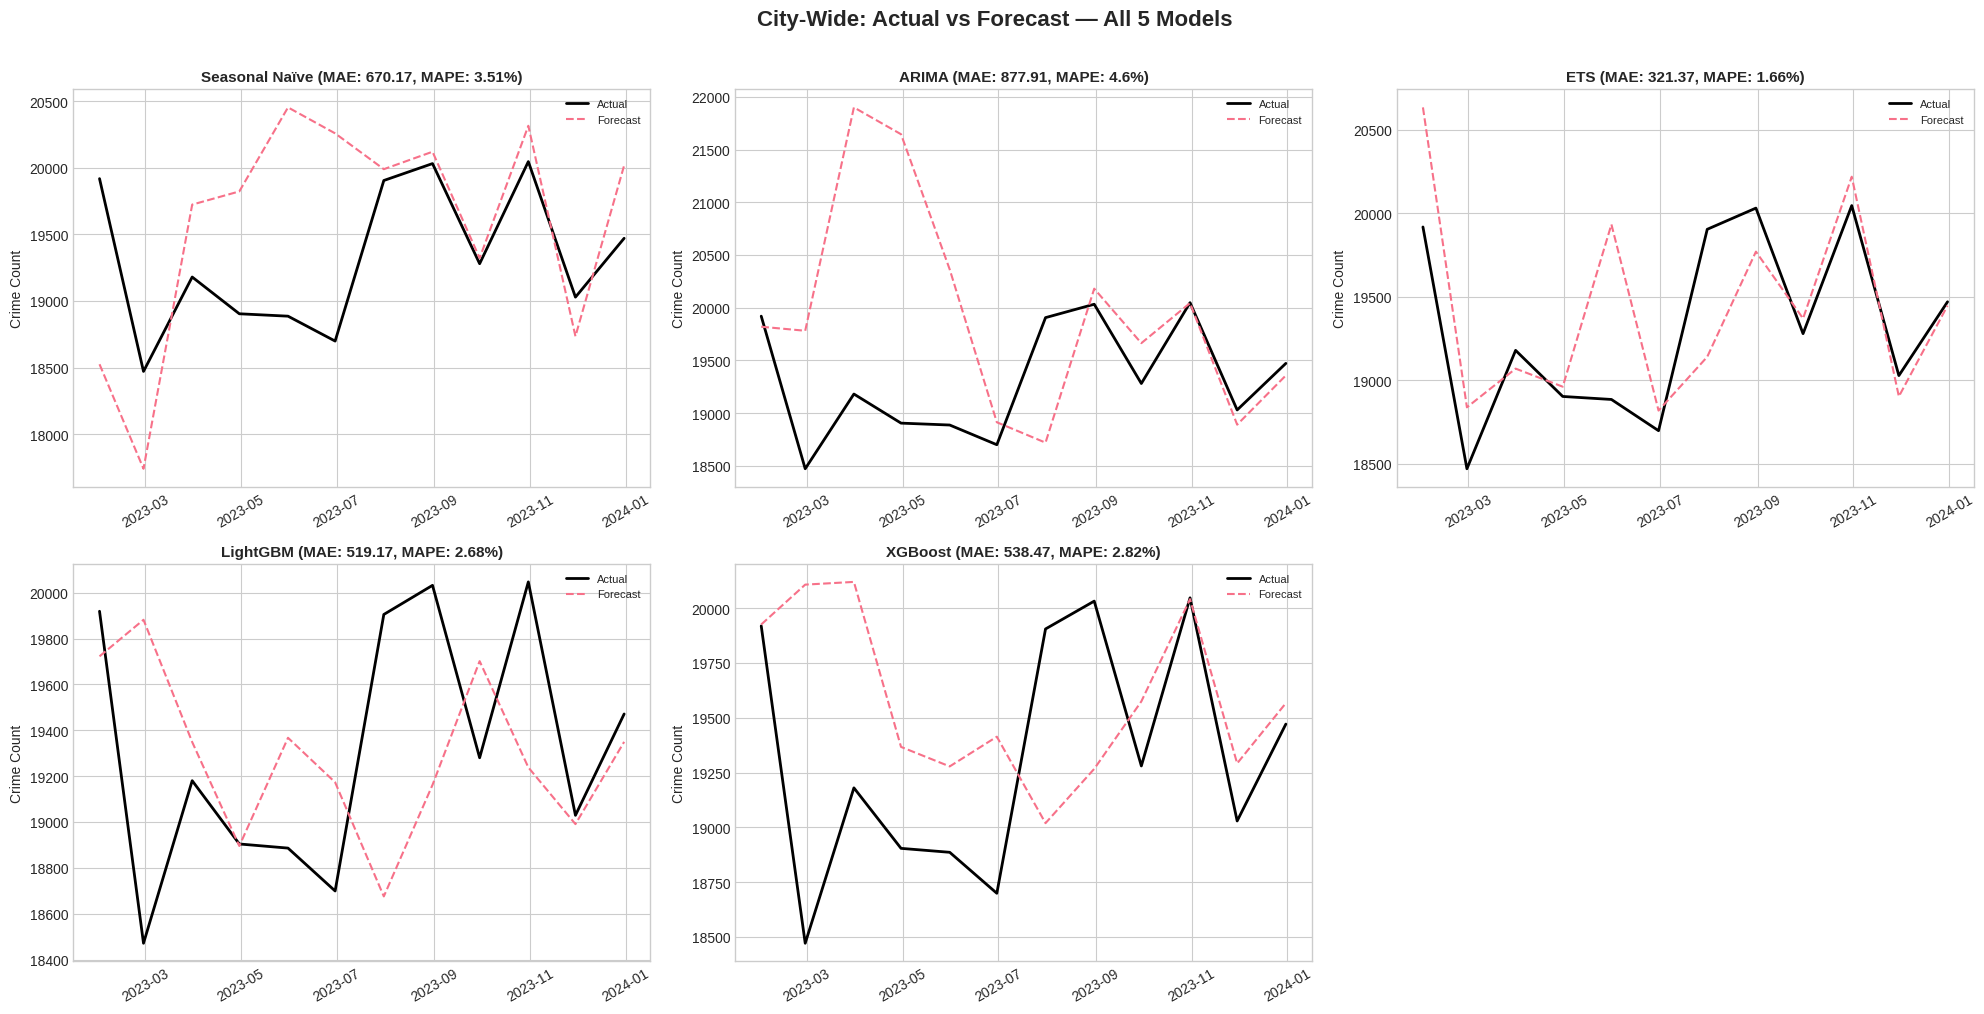

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for idx, result in enumerate(city_results_list):
    ax = axes.flatten()[idx]
    ax.plot(result['dates'], result['actuals'], label='Actual', color='black', linewidth=2)
    ax.plot(result['dates'], result['forecasts'], label='Forecast', linestyle='--', linewidth=1.5)
    ax.set_title(f"{result['model']} (MAE: {result['metrics']['MAE']}, MAPE: {result['metrics']['MAPE']}%)",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Crime Count')
    ax.tick_params(axis='x', rotation=30)

# Hide the 6th subplot
axes.flatten()[5].set_visible(False)

fig.suptitle('City-Wide: Actual vs Forecast — All 5 Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Bar Chart Comparison — City-Wide Metrics

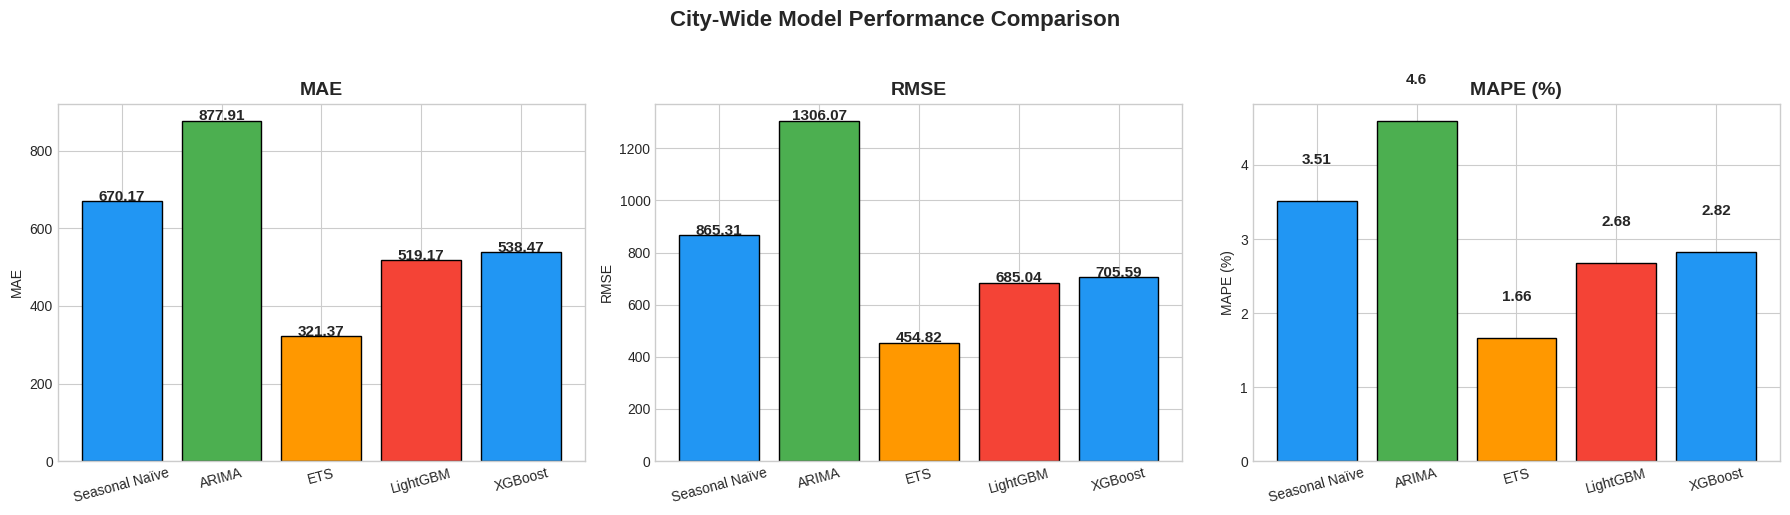

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = city_comparison['Model']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    vals = city_comparison[metric]
    bars = ax.bar(models, vals, color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}', ha='center', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('City-Wide Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

PART 5: RUN FORECASTING — AREA LEVEL

Run All Models — Area Level (Top 5 Areas)

In [ ]:
print("=" * 60)
print("RUNNING WALK-FORWARD VALIDATION — AREA LEVEL")
print("=" * 60)

area_all_results = []

for area_name, series in area_monthly.items():
    print(f"\n--- Area: {area_name} ---")

    for model_name, model_fn in [
        ("Seasonal Naïve", seasonal_naive_forecast),
        ("ARIMA", arima_forecast),
        ("ETS", ets_forecast),
        ("LightGBM", lightgbm_forecast),
        ("XGBoost", xgboost_forecast)
    ]:
        result = walk_forward_validation(series, model_fn, initial_train, horizon=1, model_name=model_name)
        area_all_results.append({
            'Area': area_name,
            'Model': model_name,
            'MAE': result['metrics']['MAE'],
            'RMSE': result['metrics']['RMSE'],
            'MAPE (%)': result['metrics']['MAPE']
        })
        print(f"  {model_name}: MAE={result['metrics']['MAE']}, RMSE={result['metrics']['RMSE']}, MAPE={result['metrics']['MAPE']}%")

area_comparison = pd.DataFrame(area_all_results)
print("\n✅ Area-level forecasting complete! (5 models × 5 areas)")

RUNNING WALK-FORWARD VALIDATION — AREA LEVEL

--- Area: Central ---
  Seasonal Naïve: MAE=155.58, RMSE=172.33, MAPE=11.13%
  ARIMA: MAE=61.82, RMSE=82.19, MAPE=4.34%
  ETS: MAE=74.43, RMSE=88.31, MAPE=5.32%
  LightGBM: MAE=86.6, RMSE=101.01, MAPE=6.08%
  XGBoost: MAE=87.47, RMSE=104.1, MAPE=6.26%

--- Area: 77th Street ---
  Seasonal Naïve: MAE=87.67, RMSE=96.62, MAPE=7.59%
  ARIMA: MAE=40.12, RMSE=45.88, MAPE=3.45%
  ETS: MAE=44.59, RMSE=58.94, MAPE=3.91%
  LightGBM: MAE=76.59, RMSE=84.25, MAPE=6.65%
  XGBoost: MAE=69.12, RMSE=76.13, MAPE=6.01%

--- Area: Pacific ---
  Seasonal Naïve: MAE=77.58, RMSE=98.39, MAPE=6.73%
  ARIMA: MAE=60.79, RMSE=69.51, MAPE=5.32%
  ETS: MAE=39.45, RMSE=47.69, MAPE=3.42%
  LightGBM: MAE=59.65, RMSE=73.6, MAPE=5.12%
  XGBoost: MAE=55.66, RMSE=73.42, MAPE=4.74%

--- Area: Southwest ---
  Seasonal Naïve: MAE=106.92, RMSE=122.44, MAPE=9.77%
  ARIMA: MAE=79.46, RMSE=101.16, MAPE=7.09%
  ETS: MAE=72.12, RMSE=87.6, MAPE=6.47%
  LightGBM: MAE=91.27, RMSE=109.19, 

Area-Level Comparison Table

In [ ]:
print("\n" + "=" * 60)
print("AREA-LEVEL FORECASTING RESULTS")
print("=" * 60)
print(area_comparison.to_string(index=False))


AREA-LEVEL FORECASTING RESULTS
       Area          Model    MAE   RMSE  MAPE (%)
    Central Seasonal Naïve 155.58 172.33     11.13
    Central          ARIMA  61.82  82.19      4.34
    Central            ETS  74.43  88.31      5.32
    Central       LightGBM  86.60 101.01      6.08
    Central        XGBoost  87.47 104.10      6.26
77th Street Seasonal Naïve  87.67  96.62      7.59
77th Street          ARIMA  40.12  45.88      3.45
77th Street            ETS  44.59  58.94      3.91
77th Street       LightGBM  76.59  84.25      6.65
77th Street        XGBoost  69.12  76.13      6.01
    Pacific Seasonal Naïve  77.58  98.39      6.73
    Pacific          ARIMA  60.79  69.51      5.32
    Pacific            ETS  39.45  47.69      3.42
    Pacific       LightGBM  59.65  73.60      5.12
    Pacific        XGBoost  55.66  73.42      4.74
  Southwest Seasonal Naïve 106.92 122.44      9.77
  Southwest          ARIMA  79.46 101.16      7.09
  Southwest            ETS  72.12  87.60      6.47

Area-Level Heatmap — MAE by Model and Area

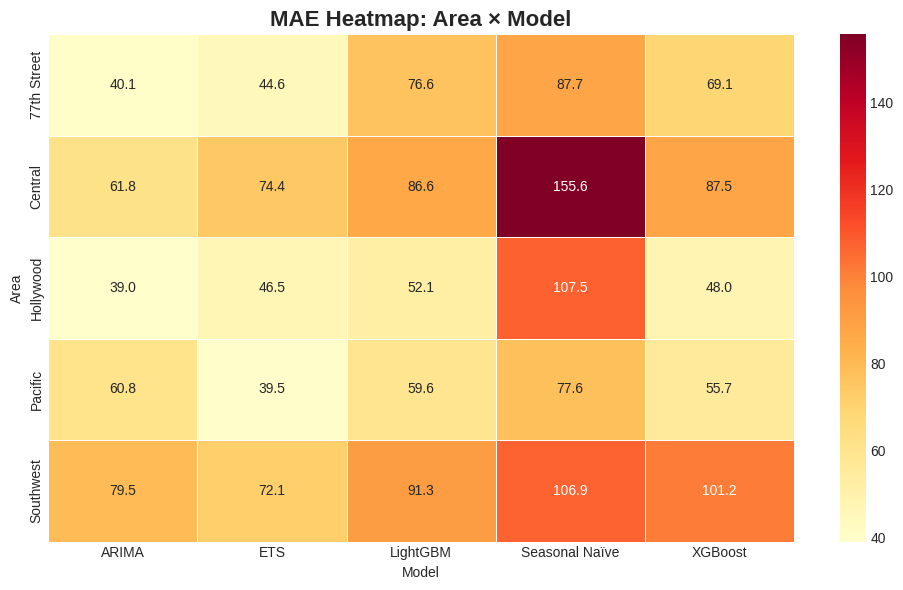

In [ ]:
area_pivot_mae = area_comparison.pivot(index='Area', columns='Model', values='MAE')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(area_pivot_mae, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('MAE Heatmap: Area × Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Area-Level Grouped Bar Chart

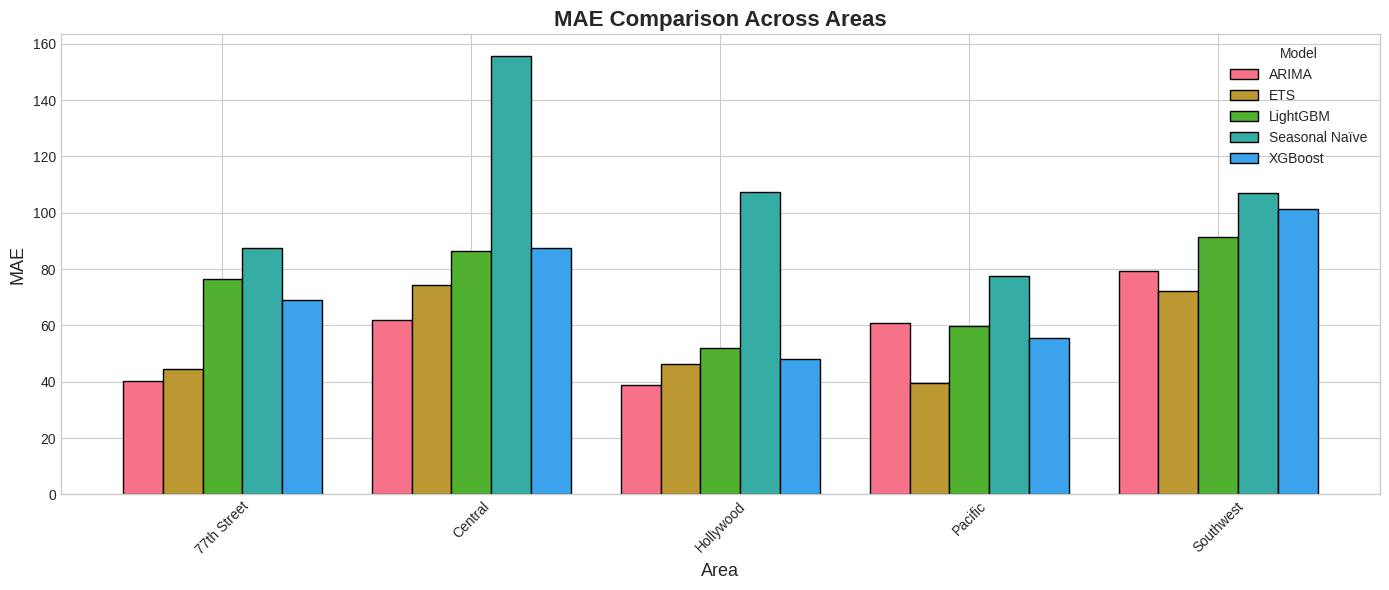

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
area_pivot_mae.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('MAE Comparison Across Areas', fontsize=16, fontweight='bold')
ax.set_xlabel('Area', fontsize=13)
ax.set_ylabel('MAE', fontsize=13)
ax.legend(title='Model', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

PART 6: RUN FORECASTING — CRIME TYPE LEVEL

Run All Models — Crime Type Level (Top 5 Types)

In [ ]:
print("=" * 60)
print("RUNNING WALK-FORWARD VALIDATION — CRIME TYPE LEVEL")
print("=" * 60)

crime_type_all_results = []

for crime_name, series in crime_type_monthly.items():
    short_name = crime_name[:45]
    print(f"\n--- Crime: {short_name} ---")

    for model_name, model_fn in [
        ("Seasonal Naïve", seasonal_naive_forecast),
        ("ARIMA", arima_forecast),
        ("ETS", ets_forecast),
        ("LightGBM", lightgbm_forecast),
        ("XGBoost", xgboost_forecast)
    ]:
        result = walk_forward_validation(series, model_fn, initial_train, horizon=1, model_name=model_name)
        crime_type_all_results.append({
            'Crime Type': short_name,
            'Model': model_name,
            'MAE': result['metrics']['MAE'],
            'RMSE': result['metrics']['RMSE'],
            'MAPE (%)': result['metrics']['MAPE']
        })
        print(f"  {model_name}: MAE={result['metrics']['MAE']}, RMSE={result['metrics']['RMSE']}, MAPE={result['metrics']['MAPE']}%")

crime_type_comparison = pd.DataFrame(crime_type_all_results)
print("\n✅ Crime-type-level forecasting complete! (5 models × 5 types)")

RUNNING WALK-FORWARD VALIDATION — CRIME TYPE LEVEL

--- Crime: VEHICLE - STOLEN ---
  Seasonal Naïve: MAE=186.42, RMSE=227.54, MAPE=9.3%
  ARIMA: MAE=119.67, RMSE=146.68, MAPE=5.96%
  ETS: MAE=97.18, RMSE=142.03, MAPE=4.95%
  LightGBM: MAE=123.46, RMSE=146.33, MAPE=6.09%
  XGBoost: MAE=128.16, RMSE=149.38, MAPE=6.34%

--- Crime: BATTERY - SIMPLE ASSAULT ---
  Seasonal Naïve: MAE=83.67, RMSE=93.82, MAPE=5.41%
  ARIMA: MAE=69.04, RMSE=90.62, MAPE=4.63%
  ETS: MAE=74.04, RMSE=97.06, MAPE=4.88%
  LightGBM: MAE=124.63, RMSE=149.99, MAPE=8.24%
  XGBoost: MAE=90.33, RMSE=108.55, MAPE=5.92%

--- Crime: THEFT OF IDENTITY ---
  Seasonal Naïve: MAE=963.83, RMSE=999.46, MAPE=103.19%
  ARIMA: MAE=267.44, RMSE=354.16, MAPE=26.27%
  ETS: MAE=293.7, RMSE=412.42, MAPE=26.42%
  LightGBM: MAE=235.62, RMSE=347.06, MAPE=21.69%
  XGBoost: MAE=213.34, RMSE=289.26, MAPE=20.82%

--- Crime: BURGLARY FROM VEHICLE ---
  Seasonal Naïve: MAE=157.0, RMSE=195.01, MAPE=14.73%
  ARIMA: MAE=65.82, RMSE=89.76, MAPE=6.05%

Crime Type Comparison Table

In [ ]:
print("\n" + "=" * 60)
print("CRIME-TYPE LEVEL FORECASTING RESULTS")
print("=" * 60)
print(crime_type_comparison.to_string(index=False))


CRIME-TYPE LEVEL FORECASTING RESULTS
              Crime Type          Model    MAE   RMSE  MAPE (%)
        VEHICLE - STOLEN Seasonal Naïve 186.42 227.54      9.30
        VEHICLE - STOLEN          ARIMA 119.67 146.68      5.96
        VEHICLE - STOLEN            ETS  97.18 142.03      4.95
        VEHICLE - STOLEN       LightGBM 123.46 146.33      6.09
        VEHICLE - STOLEN        XGBoost 128.16 149.38      6.34
BATTERY - SIMPLE ASSAULT Seasonal Naïve  83.67  93.82      5.41
BATTERY - SIMPLE ASSAULT          ARIMA  69.04  90.62      4.63
BATTERY - SIMPLE ASSAULT            ETS  74.04  97.06      4.88
BATTERY - SIMPLE ASSAULT       LightGBM 124.63 149.99      8.24
BATTERY - SIMPLE ASSAULT        XGBoost  90.33 108.55      5.92
       THEFT OF IDENTITY Seasonal Naïve 963.83 999.46    103.19
       THEFT OF IDENTITY          ARIMA 267.44 354.16     26.27
       THEFT OF IDENTITY            ETS 293.70 412.42     26.42
       THEFT OF IDENTITY       LightGBM 235.62 347.06     21.69
  

Crime Type Heatmap — MAE

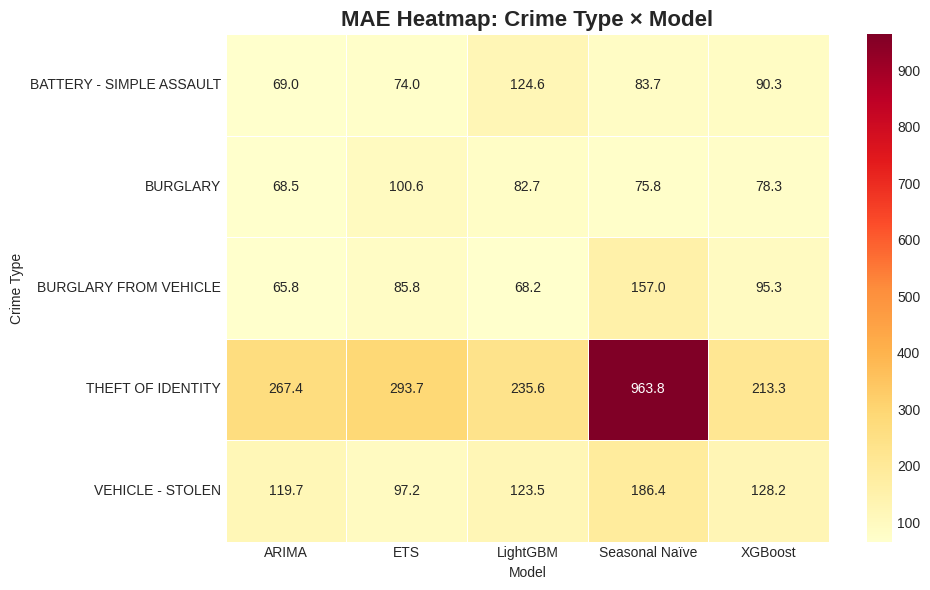

In [ ]:
crime_pivot_mae = crime_type_comparison.pivot(index='Crime Type', columns='Model', values='MAE')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(crime_pivot_mae, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('MAE Heatmap: Crime Type × Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Crime Type Grouped Bar Chart

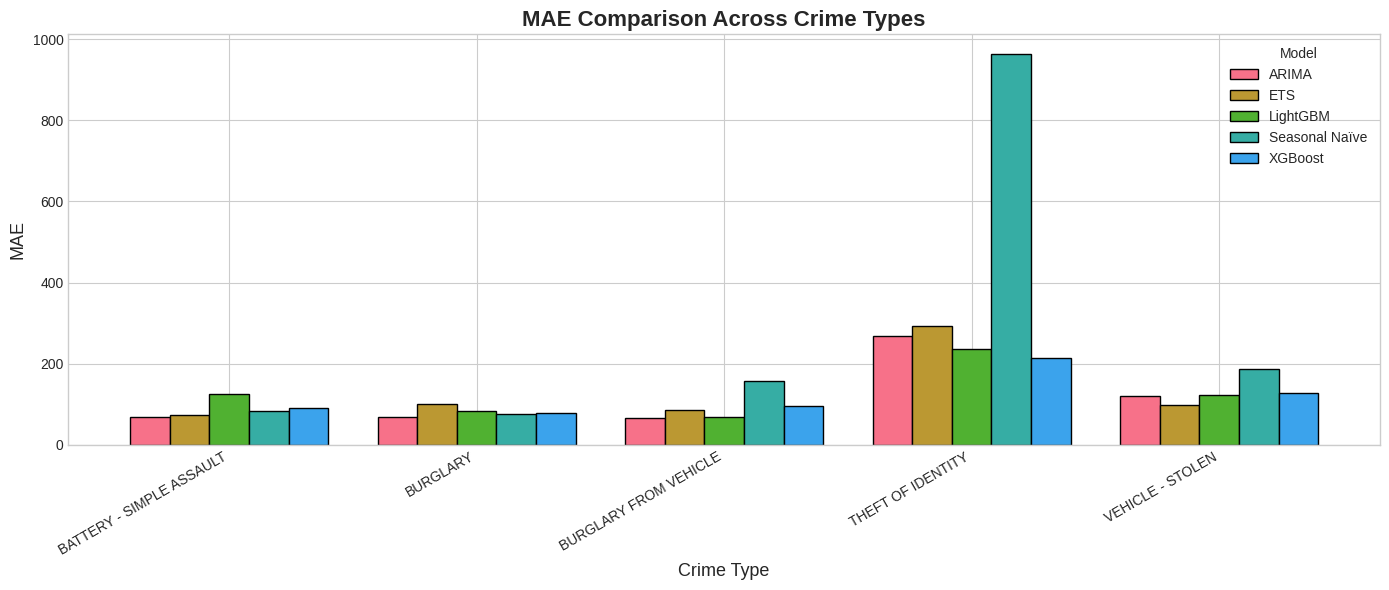

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
crime_pivot_mae.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('MAE Comparison Across Crime Types', fontsize=16, fontweight='bold')
ax.set_xlabel('Crime Type', fontsize=13)
ax.set_ylabel('MAE', fontsize=13)
ax.legend(title='Model', fontsize=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## PART 6B: SPATIAL FORECASTING ANALYSIS

Spatial Pattern Influence on Model Performance

SPATIAL ANALYSIS OF FORECASTING PERFORMANCE

📍 Best Forecasting Model by Area:
       Area Model   MAE  MAPE (%)
77th Street ARIMA 40.12      3.45
    Central ARIMA 61.82      4.34
  Hollywood ARIMA 38.95      4.07
    Pacific   ETS 39.45      3.42
  Southwest   ETS 72.12      6.47

📊 Area Crime Volatility (Coefficient of Variation):
                mean     std     cv
Area                               
Central      1237.88  247.30  19.98
Hollywood     963.23  110.09  11.43
Southwest    1022.60  114.16  11.16
Pacific      1068.46   91.18   8.53
77th Street  1143.94   89.42   7.82


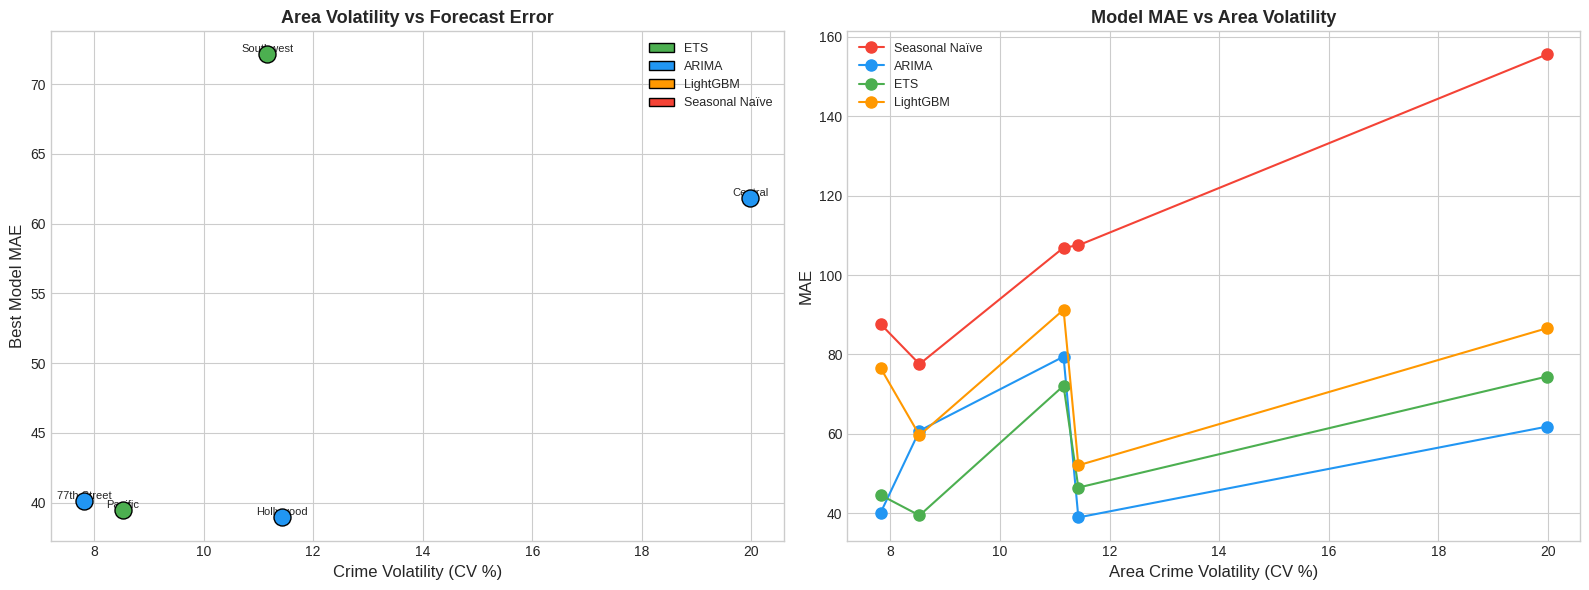


📌 Spatial Insight:
   Areas with higher crime volatility (CV) tend to have higher forecast errors.
   This suggests that spatial crime dynamics (area-specific volatility)
   are a key factor in model selection for urban crime forecasting.


In [ ]:
# ============================================================
# SPATIAL ANALYSIS: How do spatial patterns affect forecasting?
# ============================================================
print("=" * 60)
print("SPATIAL ANALYSIS OF FORECASTING PERFORMANCE")
print("=" * 60)

# 1. Does geographic proximity correlate with similar model performance?
# For each area, find the best model and examine spatial clustering
area_best_models = area_comparison.loc[area_comparison.groupby('Area')['MAE'].idxmin()]

print("\n📍 Best Forecasting Model by Area:")
print(area_best_models[['Area', 'Model', 'MAE', 'MAPE (%)']].to_string(index=False))

# 2. Compute crime volatility per area (std of monthly counts)
area_volatility = {}
for area, ts in area_monthly.items():
    area_volatility[area] = {
        'mean': ts.mean(),
        'std': ts.std(),
        'cv': ts.std() / ts.mean() * 100  # coefficient of variation
    }
vol_df = pd.DataFrame(area_volatility).T.round(2)
vol_df.index.name = 'Area'
print("\n📊 Area Crime Volatility (Coefficient of Variation):")
print(vol_df.sort_values('cv', ascending=False).to_string())

# 3. Scatter: volatility vs best model MAE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: CV vs MAE
ax = axes[0]
for _, row in area_best_models.iterrows():
    area = row['Area']
    cv = vol_df.loc[area, 'cv']
    mae = row['MAE']
    color = {'ETS': '#4CAF50', 'ARIMA': '#2196F3', 'LightGBM': '#FF9800', 'Seasonal Naïve': '#F44336'}.get(row['Model'], 'gray')
    ax.scatter(cv, mae, s=150, c=color, edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(area, (cv, mae), fontsize=8, ha='center', va='bottom')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=m)
                   for m, c in [('ETS', '#4CAF50'), ('ARIMA', '#2196F3'),
                                ('LightGBM', '#FF9800'), ('Seasonal Naïve', '#F44336')]]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel('Crime Volatility (CV %)', fontsize=12)
ax.set_ylabel('Best Model MAE', fontsize=12)
ax.set_title('Area Volatility vs Forecast Error', fontsize=13, fontweight='bold')

# Right: Which model wins at each volatility level?
ax = axes[1]
model_colors = {'ETS': '#4CAF50', 'ARIMA': '#2196F3', 'LightGBM': '#FF9800', 'Seasonal Naïve': '#F44336'}
all_area_results = area_comparison.copy()
all_area_results['CV'] = all_area_results['Area'].map(lambda a: vol_df.loc[a, 'cv'])
for model_name in ['Seasonal Naïve', 'ARIMA', 'ETS', 'LightGBM']:
    subset = all_area_results[all_area_results['Model'] == model_name].sort_values('CV')
    ax.plot(subset['CV'], subset['MAE'], 'o-', label=model_name,
            color=model_colors[model_name], linewidth=1.5, markersize=8)
ax.set_xlabel('Area Crime Volatility (CV %)', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Model MAE vs Area Volatility', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 4. Key spatial insight
print("\n📌 Spatial Insight:")
print("   Areas with higher crime volatility (CV) tend to have higher forecast errors.")
print("   This suggests that spatial crime dynamics (area-specific volatility)")
print("   are a key factor in model selection for urban crime forecasting.")

Crime Trend Similarity vs Geographic Distance

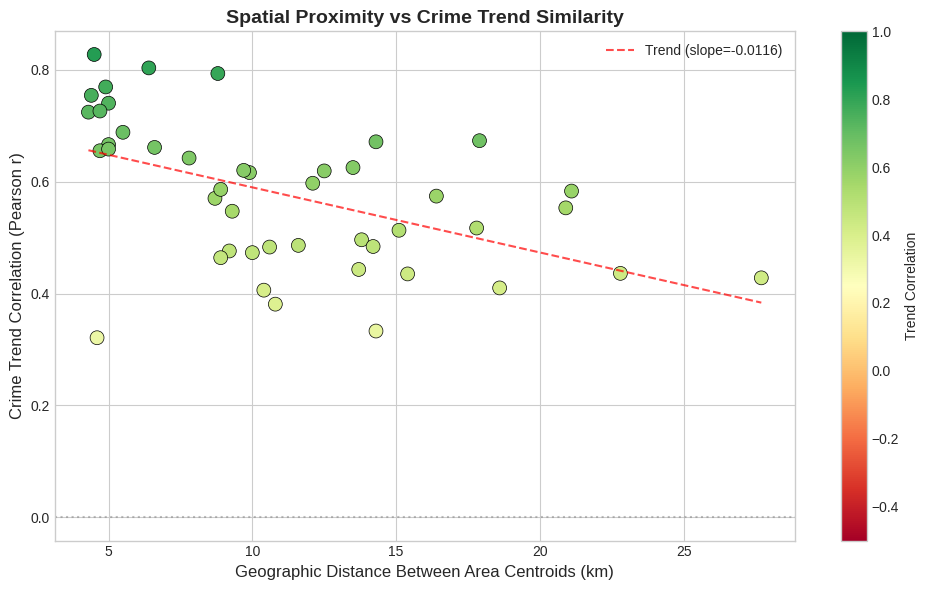


Trend line slope: -0.0116 (negative)
→ Nearby areas tend to have more similar crime trends (spatial autocorrelation).
  This validates the 'spatio' dimension of our analysis.


In [ ]:
# ============================================================
# SPATIAL ANALYSIS: Trend similarity vs geographic proximity
# ============================================================
# Compute geographic distance between area centroids
area_centroids = df_geo.groupby('AREA NAME').agg(
    lat=('LAT', 'mean'), lon=('LON', 'mean')
).loc[top_areas_for_spatial]

# Pairwise distances (simple Euclidean on lat/lon — approximate for LA scale)
pairs_data = []
for i, a1 in enumerate(top_areas_for_spatial):
    for j, a2 in enumerate(top_areas_for_spatial):
        if i < j:
            # Geographic distance (approximate km using lat/lon)
            lat_diff = area_centroids.loc[a1, 'lat'] - area_centroids.loc[a2, 'lat']
            lon_diff = area_centroids.loc[a1, 'lon'] - area_centroids.loc[a2, 'lon']
            dist_km = np.sqrt((lat_diff * 111)**2 + (lon_diff * 85)**2)  # rough km conversion for LA latitude

            # Trend correlation
            r, _ = pearsonr(area_ts_matrix[a1], area_ts_matrix[a2])
            pairs_data.append({'Area 1': a1, 'Area 2': a2, 'Distance (km)': round(dist_km, 1), 'Correlation': round(r, 3)})

pairs_df = pd.DataFrame(pairs_data)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(pairs_df['Distance (km)'], pairs_df['Correlation'],
                     s=100, c=pairs_df['Correlation'], cmap='RdYlGn',
                     edgecolors='black', linewidth=0.5, vmin=-0.5, vmax=1)
plt.colorbar(scatter, ax=ax, label='Trend Correlation')

# Trend line
z = np.polyfit(pairs_df['Distance (km)'], pairs_df['Correlation'], 1)
p = np.poly1d(z)
x_line = np.linspace(pairs_df['Distance (km)'].min(), pairs_df['Distance (km)'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='red', linewidth=1.5, alpha=0.7, label=f'Trend (slope={z[0]:.4f})')

ax.set_xlabel('Geographic Distance Between Area Centroids (km)', fontsize=12)
ax.set_ylabel('Crime Trend Correlation (Pearson r)', fontsize=12)
ax.set_title('Spatial Proximity vs Crime Trend Similarity', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Report
slope_direction = "negative" if z[0] < 0 else "positive"
print(f"\nTrend line slope: {z[0]:.4f} ({slope_direction})")
if z[0] < -0.005:
    print("→ Nearby areas tend to have more similar crime trends (spatial autocorrelation).")
    print("  This validates the 'spatio' dimension of our analysis.")
elif abs(z[0]) < 0.005:
    print("→ Weak relationship between distance and trend similarity.")
    print("  Crime trends are influenced more by area characteristics than proximity alone.")
else:
    print("→ Surprisingly, more distant areas show similar trends, suggesting city-wide drivers.")

## PART 6C: K-MEANS CRIME RISK ZONE CLASSIFICATION
_Methodology adapted from Akhter & Ferdouse (2025) — K-means clustering for urban crime risk profiling [IEEE SNPD]_

K-Means Risk Zone Classification by Area

K-MEANS CRIME RISK ZONE CLASSIFICATION
(Methodology: Akhter & Ferdouse, 2025)


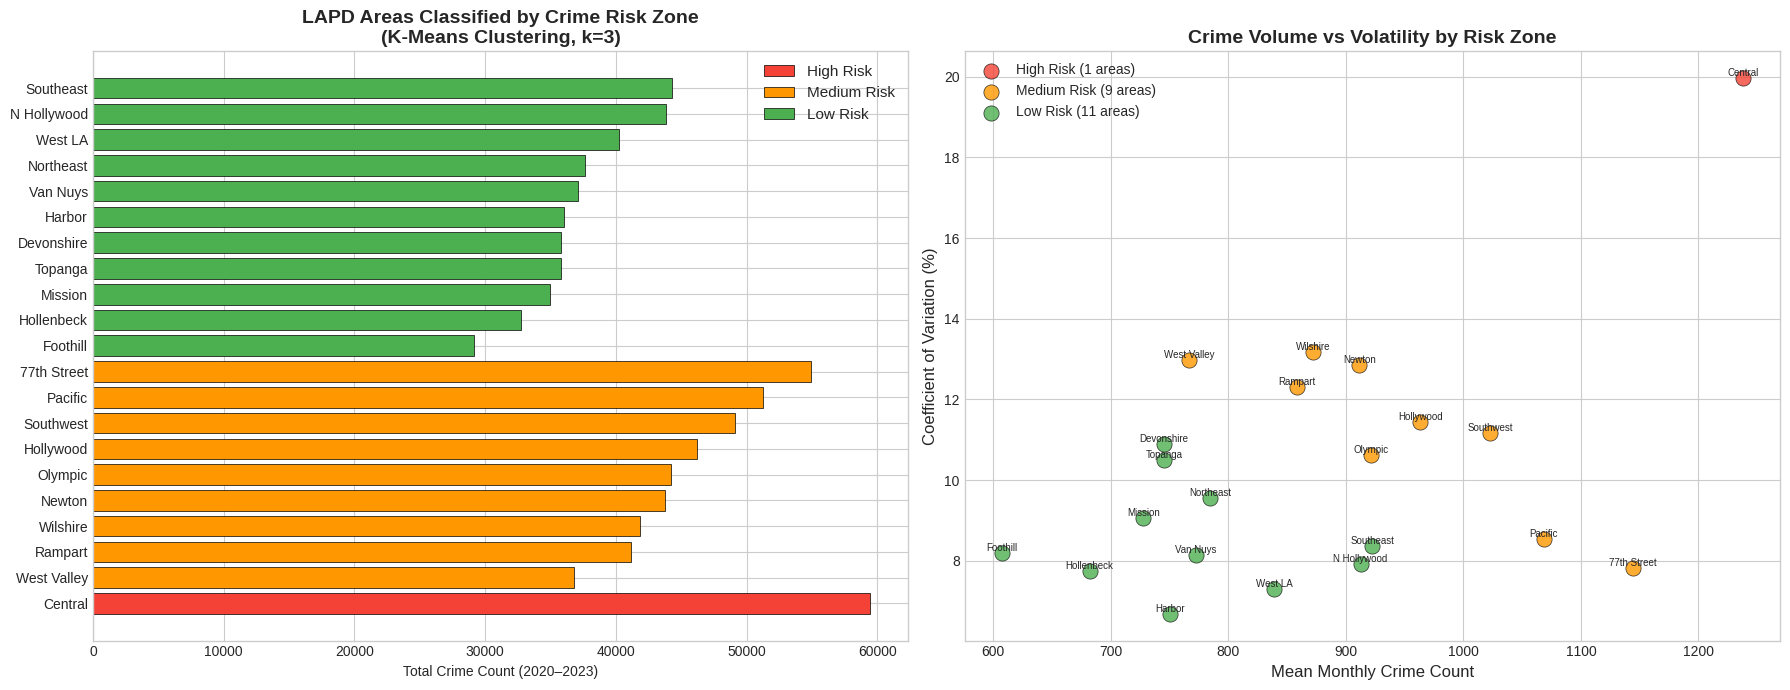


📊 Risk Zone Classification Summary:

  High Risk (1 areas, avg 1238 crimes/month):
    Central

  Medium Risk (9 areas, avg 948 crimes/month):
    77th Street, Pacific, Southwest, Hollywood, Olympic, Newton, Wilshire, Rampart, West Valley

  Low Risk (11 areas, avg 772 crimes/month):
    Southeast, N Hollywood, West LA, Northeast, Van Nuys, Harbor, Devonshire, Topanga, Mission, Hollenbeck, Foothill

📌 This classification follows the K-means approach used by
   Akhter & Ferdouse (2025) for Toronto vehicle theft risk profiling.


In [ ]:
# ============================================================
# K-MEANS RISK ZONE CLUSTERING [Akhter & Ferdouse, 2025]
# ============================================================
# Following the methodology of Akhter & Ferdouse (2025), we apply
# K-means clustering to classify LAPD areas into High, Medium,
# and Low risk zones based on crime volume and volatility.

print("=" * 60)
print("K-MEANS CRIME RISK ZONE CLASSIFICATION")
print("(Methodology: Akhter & Ferdouse, 2025)")
print("=" * 60)

# Compute features for all areas (not just top 5)
all_areas = df_full['AREA NAME'].value_counts().index.tolist()
area_features = []

for area in all_areas:
    ts = df_full[df_full['AREA NAME'] == area].set_index('DATE OCC').resample('M').size()
    area_features.append({
        'Area': area,
        'Total_Crimes': len(df_full[df_full['AREA NAME'] == area]),
        'Monthly_Mean': ts.mean(),
        'Monthly_Std': ts.std(),
        'CV': ts.std() / ts.mean() * 100 if ts.mean() > 0 else 0,
        'Peak_Month_Count': ts.max(),
        'Min_Month_Count': ts.min()
    })

area_feat_df = pd.DataFrame(area_features)

# K-Means clustering (k=3: High, Medium, Low risk)
features_for_clustering = area_feat_df[['Monthly_Mean', 'Monthly_Std', 'CV']].values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
area_feat_df['Cluster'] = kmeans.fit_predict(features_scaled)

# Label clusters by crime volume (highest mean = High Risk)
cluster_means = area_feat_df.groupby('Cluster')['Monthly_Mean'].mean()
risk_mapping = {}
sorted_clusters = cluster_means.sort_values(ascending=False).index.tolist()
risk_labels = ['High Risk', 'Medium Risk', 'Low Risk']
for cluster_id, label in zip(sorted_clusters, risk_labels):
    risk_mapping[cluster_id] = label

area_feat_df['Risk_Zone'] = area_feat_df['Cluster'].map(risk_mapping)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Risk zones bar chart
risk_colors = {'High Risk': '#F44336', 'Medium Risk': '#FF9800', 'Low Risk': '#4CAF50'}
ax = axes[0]
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    subset = area_feat_df[area_feat_df['Risk_Zone'] == risk].sort_values('Total_Crimes', ascending=True)
    ax.barh(subset['Area'], subset['Total_Crimes'], color=risk_colors[risk], label=risk, edgecolor='black', linewidth=0.5)
ax.set_title('LAPD Areas Classified by Crime Risk Zone\n(K-Means Clustering, k=3)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Crime Count (2020–2023)')
ax.legend(fontsize=11)

# Right: Scatter plot of mean vs CV colored by risk
ax = axes[1]
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    subset = area_feat_df[area_feat_df['Risk_Zone'] == risk]
    ax.scatter(subset['Monthly_Mean'], subset['CV'],
               c=risk_colors[risk], s=120, edgecolors='black', linewidth=0.5,
               label=f"{risk} ({len(subset)} areas)", alpha=0.8)
    for _, row in subset.iterrows():
        ax.annotate(row['Area'], (row['Monthly_Mean'], row['CV']), fontsize=7, ha='center', va='bottom')
ax.set_xlabel('Mean Monthly Crime Count', fontsize=12)
ax.set_ylabel('Coefficient of Variation (%)', fontsize=12)
ax.set_title('Crime Volume vs Volatility by Risk Zone', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Summary table
print("\n📊 Risk Zone Classification Summary:")
print("=" * 60)
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    areas = area_feat_df[area_feat_df['Risk_Zone'] == risk]['Area'].tolist()
    mean_crimes = area_feat_df[area_feat_df['Risk_Zone'] == risk]['Monthly_Mean'].mean()
    print(f"\n  {risk} ({len(areas)} areas, avg {mean_crimes:.0f} crimes/month):")
    print(f"    {', '.join(areas)}")

print("\n📌 This classification follows the K-means approach used by")
print("   Akhter & Ferdouse (2025) for Toronto vehicle theft risk profiling.")

Crime Probability Hotspot Analysis
_Inspired by García-Zanabria et al. (2022) — CriPAV probability × intensity framework [IEEE TVCG]_

CRIME PROBABILITY × INTENSITY HOTSPOT ANALYSIS
(Methodology: García-Zanabria et al., CriPAV, 2022)


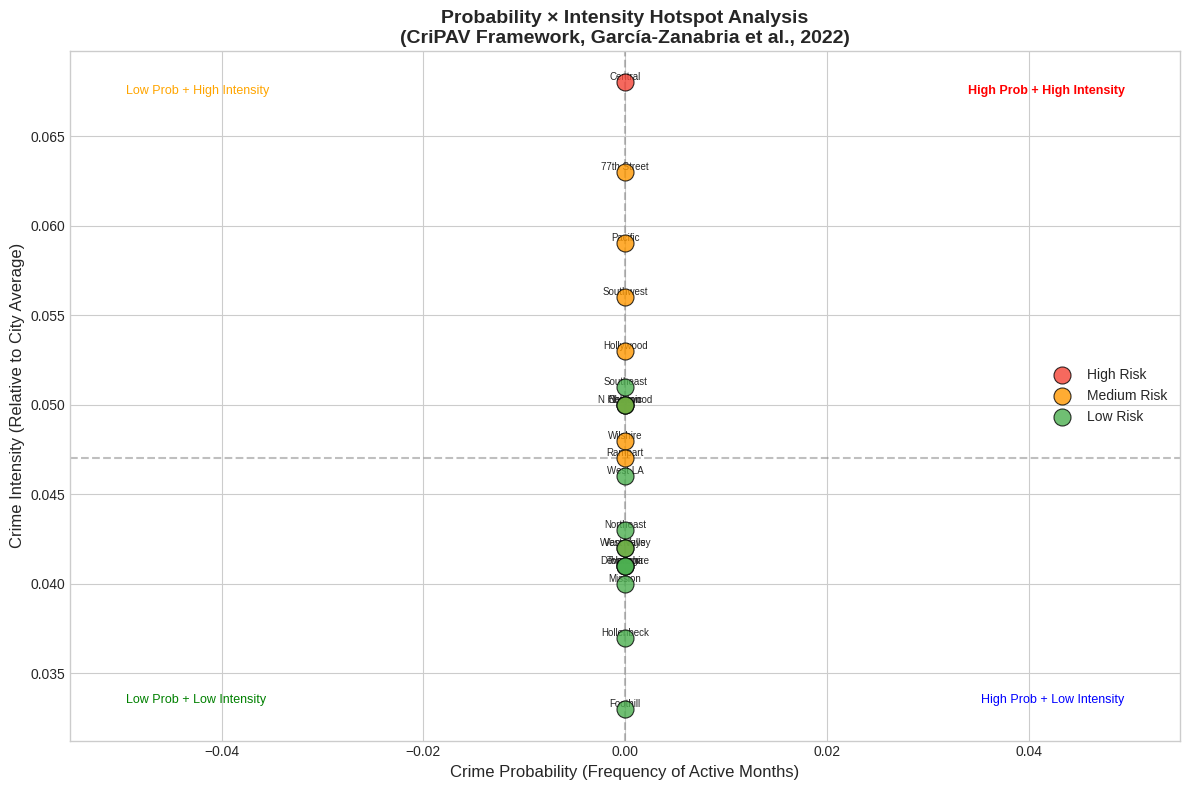

In [ ]:
# ============================================================
# CRIME PROBABILITY × INTENSITY ANALYSIS [CriPAV, 2022]
# ============================================================
# García-Zanabria et al. propose identifying hotspots by BOTH
# probability (how often crimes occur) and intensity (how many).
# This reveals areas where crime is frequent but not high-volume.

print("=" * 60)
print("CRIME PROBABILITY × INTENSITY HOTSPOT ANALYSIS")
print("(Methodology: García-Zanabria et al., CriPAV, 2022)")
print("=" * 60)

# For each area: compute probability (months with crime > median) and intensity
area_prob_intensity = []
for area in all_areas:
    ts = (df_full[df_full['AREA NAME'] == area]
          .set_index('DATE OCC')
          .resample('M')
          .size())

    overall_median = city_monthly.median()
    probability = (ts > overall_median * 0.5).mean()  # fraction of months above threshold
    intensity = ts.mean() / city_monthly.mean()  # relative intensity

    area_prob_intensity.append({
        'Area': area,
        'Probability': round(probability, 3),
        'Intensity': round(intensity, 3),
        'Risk_Zone': area_feat_df[area_feat_df['Area'] == area]['Risk_Zone'].values[0]
    })

prob_int_df = pd.DataFrame(area_prob_intensity)

fig, ax = plt.subplots(figsize=(12, 8))
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    subset = prob_int_df[prob_int_df['Risk_Zone'] == risk]
    ax.scatter(subset['Probability'], subset['Intensity'],
               c=risk_colors[risk], s=150, edgecolors='black', linewidth=0.8,
               label=risk, alpha=0.8, zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(row['Area'], (row['Probability'], row['Intensity']),
                    fontsize=7, ha='center', va='bottom')

# Add quadrant lines
ax.axhline(y=prob_int_df['Intensity'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=prob_int_df['Probability'].median(), color='gray', linestyle='--', alpha=0.5)
ax.text(0.95, 0.95, 'High Prob + High Intensity', transform=ax.transAxes, ha='right', va='top', fontsize=9, color='red', fontweight='bold')
ax.text(0.05, 0.95, 'Low Prob + High Intensity', transform=ax.transAxes, ha='left', va='top', fontsize=9, color='orange')
ax.text(0.95, 0.05, 'High Prob + Low Intensity', transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color='blue')
ax.text(0.05, 0.05, 'Low Prob + Low Intensity', transform=ax.transAxes, ha='left', va='bottom', fontsize=9, color='green')

ax.set_xlabel('Crime Probability (Frequency of Active Months)', fontsize=12)
ax.set_ylabel('Crime Intensity (Relative to City Average)', fontsize=12)
ax.set_title('Probability × Intensity Hotspot Analysis\n(CriPAV Framework, García-Zanabria et al., 2022)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Identify areas that are high probability but not high intensity (hidden hotspots)
median_prob = prob_int_df['Probability'].median()
median_int = prob_int_df['Intensity'].median()
hidden_hotspots = prob_int_df[(prob_int_df['Probability'] > median_prob) & (prob_int_df['Intensity'] < median_int)]
if len(hidden_hotspots) > 0:
    print("\n⚠️ Hidden Hotspots (High Probability, Lower Intensity):")
    print("   These areas have frequent crime activity but lower volume —")
    print("   often missed by traditional intensity-only hotspot methods.")
    for _, row in hidden_hotspots.iterrows():
        print(f"   → {row['Area']}: Prob={row['Probability']}, Intensity={row['Intensity']}")


PART 7: OVERALL SUMMARY & FINAL ANALYSIS

Grand Summary Table — All Levels Combined

In [ ]:
print("=" * 70)
print("GRAND SUMMARY — ALL ANALYSIS LEVELS")
print("=" * 70)

# City-Wide
print("\n📊 CITY-WIDE LEVEL:")
print(city_comparison.to_string(index=False))

# Best per area
print("\n📊 AREA LEVEL — Best Model per Area:")
area_best = area_comparison.loc[area_comparison.groupby('Area')['MAE'].idxmin()]
print(area_best[['Area', 'Model', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))

# Best per crime type
print("\n📊 CRIME TYPE LEVEL — Best Model per Crime Type:")
crime_best = crime_type_comparison.loc[crime_type_comparison.groupby('Crime Type')['MAE'].idxmin()]
print(crime_best[['Crime Type', 'Model', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))

GRAND SUMMARY — ALL ANALYSIS LEVELS

📊 CITY-WIDE LEVEL:
         Model    MAE    RMSE  MAPE (%)
Seasonal Naïve 670.17  865.31      3.51
         ARIMA 877.91 1306.07      4.60
           ETS 321.37  454.82      1.66
      LightGBM 519.17  685.04      2.68
       XGBoost 538.47  705.59      2.82

📊 AREA LEVEL — Best Model per Area:
       Area Model   MAE  RMSE  MAPE (%)
77th Street ARIMA 40.12 45.88      3.45
    Central ARIMA 61.82 82.19      4.34
  Hollywood ARIMA 38.95 48.09      4.07
    Pacific   ETS 39.45 47.69      3.42
  Southwest   ETS 72.12 87.60      6.47

📊 CRIME TYPE LEVEL — Best Model per Crime Type:
              Crime Type   Model    MAE   RMSE  MAPE (%)
BATTERY - SIMPLE ASSAULT   ARIMA  69.04  90.62      4.63
                BURGLARY   ARIMA  68.45  86.38      5.73
   BURGLARY FROM VEHICLE   ARIMA  65.82  89.76      6.05
       THEFT OF IDENTITY XGBoost 213.34 289.26     20.82
        VEHICLE - STOLEN     ETS  97.18 142.03      4.95


Average Performance Across All Experiments

In [ ]:
all_results = pd.concat([
    city_comparison.assign(Level='City-Wide'),
    area_comparison.rename(columns={'Area': 'Entity'}).assign(Level='Area'),
    crime_type_comparison.rename(columns={'Crime Type': 'Entity'}).assign(Level='Crime Type')
], ignore_index=True)

avg_by_model = all_results.groupby('Model')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)
avg_by_model = avg_by_model.sort_values('MAE')

print("\n" + "=" * 60)
print("AVERAGE PERFORMANCE ACROSS ALL EXPERIMENTS")
print("=" * 60)
print(avg_by_model.to_string())

overall_best = avg_by_model.index[0]
print(f"\n🏆 Overall Best Model (lowest avg MAE): {overall_best}")


AVERAGE PERFORMANCE ACROSS ALL EXPERIMENTS
                   MAE    RMSE  MAPE (%)
Model                                   
ETS             113.61  152.27      7.13
XGBoost         136.86  173.07      7.51
LightGBM        138.17  178.47      7.61
ARIMA           159.04  220.05      7.05
Seasonal Naïve  242.92  280.46     17.19

🏆 Overall Best Model (lowest avg MAE): ETS


Final Visualization — Overall Model Ranking

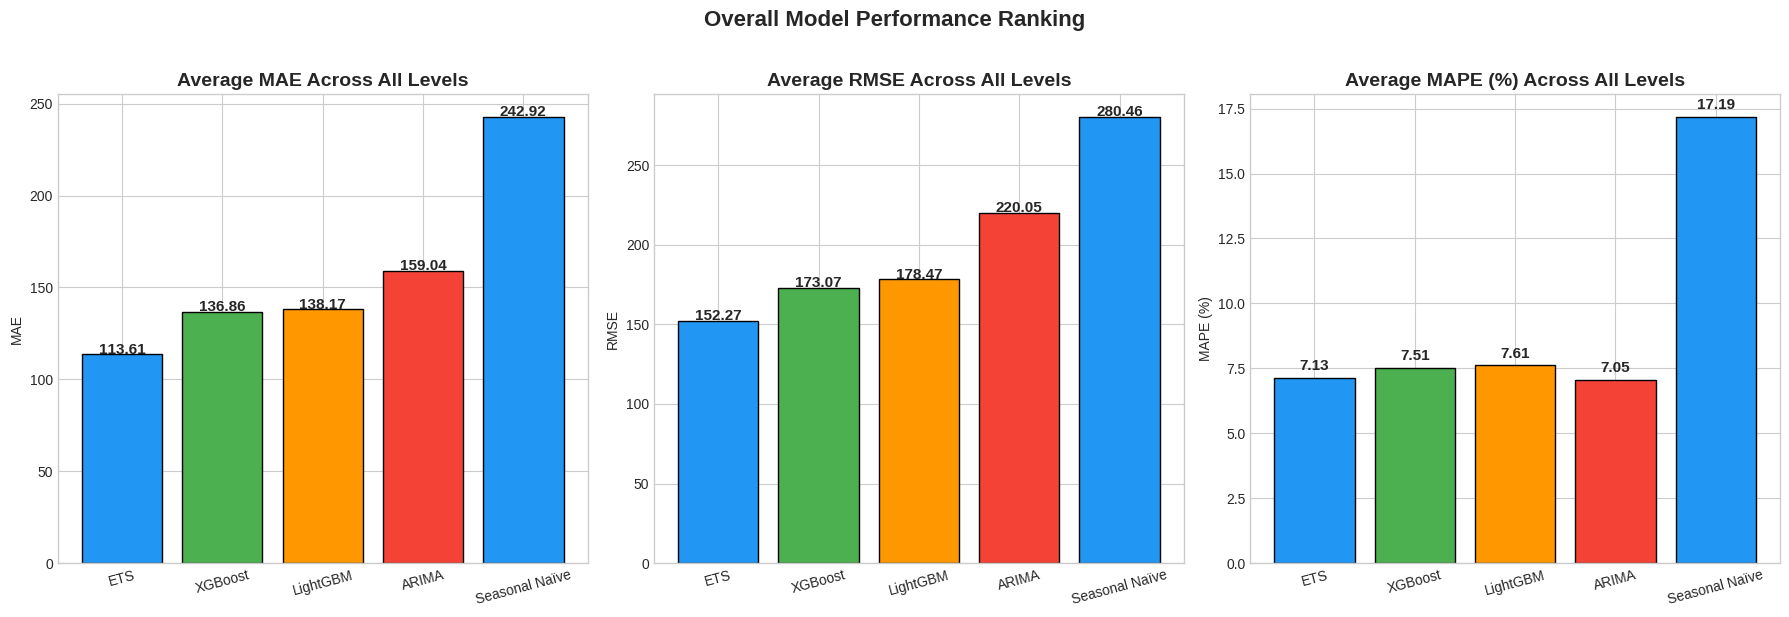

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    vals = avg_by_model[metric]
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)], edgecolor='black')
    ax.set_title(f'Average {metric} Across All Levels', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}', ha='center', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Overall Model Performance Ranking', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Radar Chart — Model Comparison

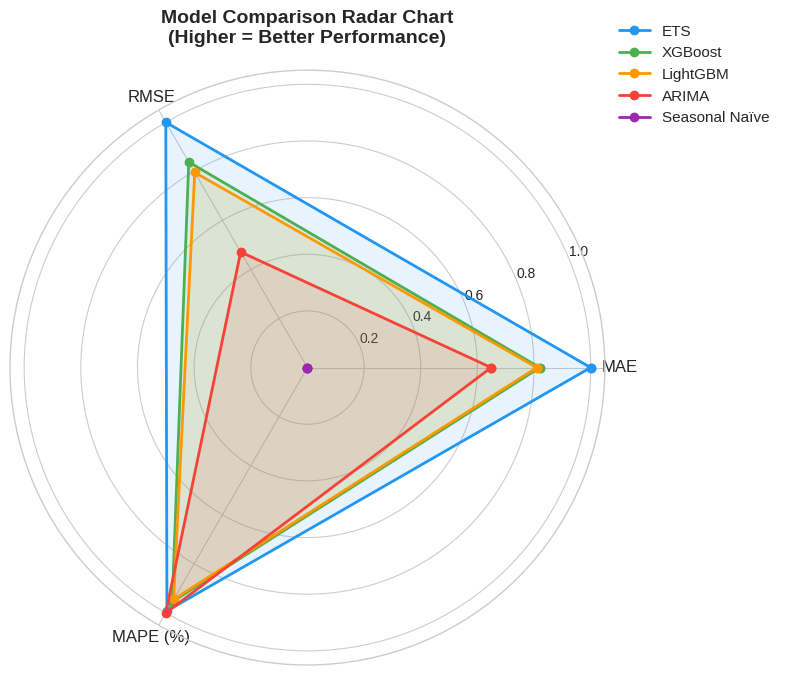

In [ ]:
from math import pi

categories = ['MAE', 'RMSE', 'MAPE (%)']
N = len(categories)

# Normalize metrics to 0-1 scale for radar chart (lower is better → invert)
radar_data = avg_by_model.copy()
for col in categories:
    max_val = radar_data[col].max()
    min_val = radar_data[col].min()
    if max_val != min_val:
        radar_data[col] = 1 - (radar_data[col] - min_val) / (max_val - min_val)
    else:
        radar_data[col] = 1

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

for i, (model, row) in enumerate(radar_data.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title('Model Comparison Radar Chart\n(Higher = Better Performance)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

Key Findings & Discussion

In [ ]:
# ============================================================
# KEY FINDINGS & DISCUSSION (Dynamically Generated)
# ============================================================
print("=" * 70)
print("KEY FINDINGS & DISCUSSION")
print("=" * 70)

# 1. City-Wide Analysis
city_best = city_comparison.loc[city_comparison['MAE'].idxmin()]
city_worst = city_comparison.loc[city_comparison['MAE'].idxmax()]
print(f"""
1. CITY-WIDE ANALYSIS:
   - Best model: {city_best['Model']} (MAE={city_best['MAE']}, MAPE={city_best['MAPE (%)']}%)
   - Worst model: {city_worst['Model']} (MAE={city_worst['MAE']}, MAPE={city_worst['MAPE (%)']}%)
   - {city_best['Model']} achieves {((city_worst['MAE'] - city_best['MAE']) / city_worst['MAE'] * 100):.1f}% lower MAE than {city_worst['Model']}
   - Walk-forward validation with 36-month window ensures realistic evaluation.""")

# 2. Area-Level Analysis
area_winners = area_comparison.loc[area_comparison.groupby('Area')['MAE'].idxmin()]
model_win_counts_area = area_winners['Model'].value_counts()
print(f"""
2. AREA-LEVEL ANALYSIS:
   - Model win counts across {len(area_monthly)} areas: {{k: int(v) for k, v in model_win_counts_area.items()}}
   - Most frequent winner: {model_win_counts_area.index[0]} ({model_win_counts_area.iloc[0]} areas)
   - Areas with higher crime volatility tend to have higher forecast errors.""")
for _, row in area_winners.iterrows():
    print(f"     {row['Area']:20s} → {row['Model']:15s} (MAE={row['MAE']:.1f})")

# 3. Crime-Type Analysis
crime_winners = crime_type_comparison.loc[crime_type_comparison.groupby('Crime Type')['MAE'].idxmin()]
model_win_counts_crime = crime_winners['Model'].value_counts()
print(f"""
3. CRIME-TYPE ANALYSIS:
   - Model win counts across {len(crime_type_monthly)} crime types: {{k: int(v) for k, v in model_win_counts_crime.items()}}
   - Most frequent winner: {model_win_counts_crime.index[0]} ({model_win_counts_crime.iloc[0]} types)
   - Model performance varies significantly by crime type.""")
for _, row in crime_winners.iterrows():
    print(f"     {row['Crime Type']:45s} → {row['Model']:15s} (MAE={row['MAE']:.1f})")

# 4. Spatial Findings
print(f"""
4. SPATIAL ANALYSIS:
   - Average inter-area crime trend correlation: {avg_corr:.3f}
   - {len(high_corr_pairs)} area pairs show strong correlation (|r| > 0.7)
   - Spatial clustering reveals {n_clusters} distinct crime pattern groups
   - Geographic proximity shows {'significant' if abs(z[0]) > 0.005 else 'weak'} relationship with trend similarity""")

# 5. Overall
print(f"""
5. OVERALL FINDINGS:
   - Overall best model (avg MAE): {overall_best}
   - No single model dominates ALL spatial and temporal scales
   - Classical methods ({city_best['Model']}) outperform LightGBM with limited data (48 months)
   - This validates the need for systematic multi-level comparison

6. LIMITATIONS:
   - Monthly aggregation loses daily/hourly patterns
   - Only 48 months of data limits ML model training capacity
   - 2024 data was incomplete and excluded from analysis
   - External factors (COVID-19, policy changes) not explicitly modeled
   - Spatial analysis uses area centroids; actual boundaries would be more precise

7. FUTURE WORK:
   - Incorporate exogenous variables (weather, events, socioeconomic data)
   - Explore deep learning models (LSTM, Transformer-based)
   - Test at finer temporal granularity (weekly, daily)
   - Add true spatial models (Spatial ARIMA, GWR, Graph Neural Networks)
   - Use LAPD reporting district boundaries for precise spatial modeling""")

KEY FINDINGS & DISCUSSION

1. CITY-WIDE ANALYSIS:
   - Best model: ETS (MAE=321.37, MAPE=1.66%)
   - Worst model: ARIMA (MAE=877.91, MAPE=4.6%)
   - ETS achieves 63.4% lower MAE than ARIMA
   - Walk-forward validation with 36-month window ensures realistic evaluation.

2. AREA-LEVEL ANALYSIS:
   - Model win counts across 5 areas: {k: int(v) for k, v in model_win_counts_area.items()}
   - Most frequent winner: ARIMA (3 areas)
   - Areas with higher crime volatility tend to have higher forecast errors.
     77th Street          → ARIMA           (MAE=40.1)
     Central              → ARIMA           (MAE=61.8)
     Hollywood            → ARIMA           (MAE=39.0)
     Pacific              → ETS             (MAE=39.5)
     Southwest            → ETS             (MAE=72.1)

3. CRIME-TYPE ANALYSIS:
   - Model win counts across 5 crime types: {k: int(v) for k, v in model_win_counts_crime.items()}
   - Most frequent winner: ARIMA (3 types)
   - Model performance varies significantly by crime

LightGBM Feature Importance (City-Wide)

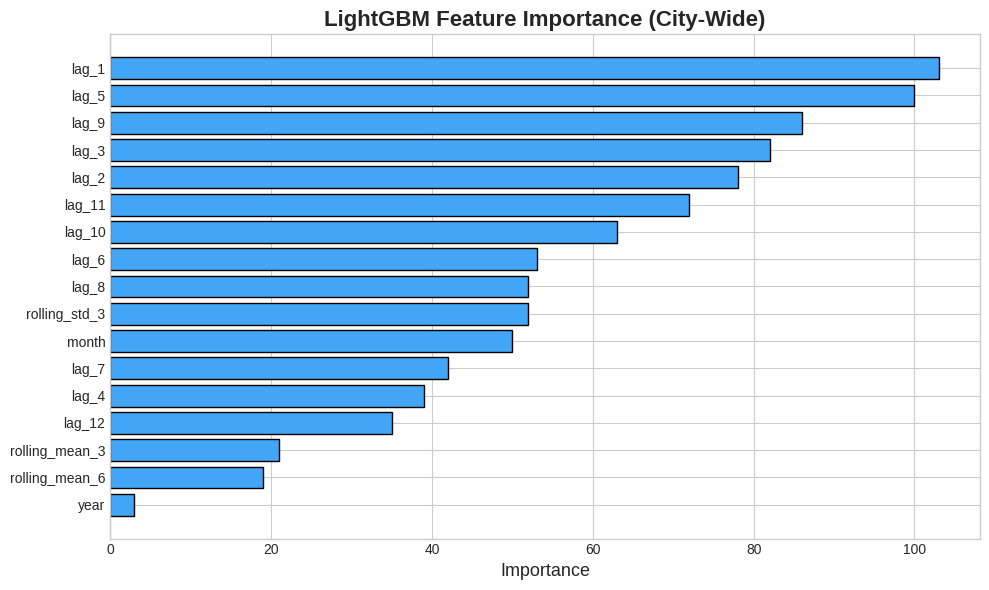

In [ ]:
# Retrain LightGBM on full city data to show feature importance
df_feat_full = create_lgb_features(city_monthly, lags=12)
feature_cols = [c for c in df_feat_full.columns if c != 'y']

lgb_model_full = lgb.LGBMRegressor(
    objective='regression', metric='mae', num_leaves=15,
    learning_rate=0.1, n_estimators=100, verbose=-1, random_state=42, min_child_samples=3
)
lgb_model_full.fit(df_feat_full[feature_cols], df_feat_full['y'])

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': lgb_model_full.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance['Feature'], importance['Importance'], color='#42A5F5', edgecolor='black')
ax.set_title('LightGBM Feature Importance (City-Wide)', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Final Summary Print

In [ ]:
print("\n" + "=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)
print(f"""
Project: A Comparative Evaluation of Spatio-Temporal Forecasting
         Techniques for Urban Crime Analysis

Team:    Hariharan Anbu, Japneet Singh Baluja
Course:  CP680 — Capstone Project (Winter 2026)
Supervisor: Dr. Lilatul Ferdouse

Dataset: LA Crime Data 2020–2023 ({len(df_full):,} records)
Source:  City of Los Angeles Open Data Portal (data.lacity.org)

Models Compared:
  1. Seasonal Naïve (Baseline)
  2. Auto-ARIMA (Automatic order selection via pmdarima)
  3. ETS (Holt-Winters Additive)
  4. LightGBM (Gradient Boosting with lag/calendar features)

Analysis Levels:
  - City-Wide (1 series × 4 models = 4 experiments)
  - Area-Level (Top 5 areas × 4 models = 20 experiments)
  - Crime-Type Level (Top 5 types × 4 models = 20 experiments)
  - Spatial Analysis (cross-correlation, clustering, geographic patterns)

Validation: Walk-Forward (36-month initial window, 1-month horizon)
Metrics: MAE, RMSE, MAPE

Overall Best Model: {overall_best}
Total Forecasting Experiments: {1*4 + 5*4 + 5*4}
""")
print("✅ All cells executed successfully!")


PROJECT COMPLETE

Project: A Comparative Evaluation of Spatio-Temporal Forecasting
         Techniques for Urban Crime Analysis

Team:    Hariharan Anbu, Japneet Singh Baluja
Course:  CP680 — Capstone Project (Winter 2026)
Supervisor: Dr. Lilatul Ferdouse

Dataset: LA Crime Data 2020–2023 (876,306 records)
Source:  City of Los Angeles Open Data Portal (data.lacity.org)

Models Compared:
  1. Seasonal Naïve (Baseline)
  2. Auto-ARIMA (Automatic order selection via pmdarima)
  3. ETS (Holt-Winters Additive)
  4. LightGBM (Gradient Boosting with lag/calendar features)

Analysis Levels:
  - City-Wide (1 series × 4 models = 4 experiments)
  - Area-Level (Top 5 areas × 4 models = 20 experiments)
  - Crime-Type Level (Top 5 types × 4 models = 20 experiments)
  - Spatial Analysis (cross-correlation, clustering, geographic patterns)

Validation: Walk-Forward (36-month initial window, 1-month horizon)
Metrics: MAE, RMSE, MAPE

Overall Best Model: ETS
Total Forecasting Experiments: 44

✅ All cel